In [2]:
import sys
import os
import warnings
warnings.simplefilter("ignore")
# parentdir = os.path.abspath('../..')
# sys.path.insert(0, parentdir) 
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_enable_triton_softmax_fusion=true '
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_async_collectives=true '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
    '--xla_gpu_enable_highest_priority_async_stream=true '
)
if 'graphviz' not in os.environ['PATH']:
    os.environ['PATH'] = '/opt/apps/pkgs/graphviz/12.2.1/intel64/gnu_12.2.0/bin:' + os.environ['PATH']

[CudaDevice(id=0)]


In [3]:

DATA_DIR = "../../Data/WFI2033"
raw_data_path = os.path.join(DATA_DIR, "jw01198-o004_t004_nircam_clear-f115w_i2d.fits")
data_path = os.path.join(DATA_DIR, "jw01198-o004_t004_nircam_clear-f115w_i2d_cut_x6985_y3594_150.fits")
mask_path = os.path.join("data/mask_hmc.fits")
maskout_path = os.path.join(DATA_DIR, "mask_out_center.fits")

with fits.open(raw_data_path, memmap=True) as hdul_raw:
    raw_header = hdul_raw["SCI"].header if "SCI" in hdul_raw else hdul_raw[0].header
    exposure_time = float(raw_header.get("EXPTIME", raw_header.get("TEXPTIME", raw_header.get("XPOSURE", 1.0))))
pix_scale = float(np.sqrt(raw_header["PIXAR_A2"]))

with fits.open(data_path, memmap=True) as hdul:
    data = jnp.array(hdul["SCI"].data) if "SCI" in hdul else jnp.array(hdul[0].data)
    rms_file = jnp.array(hdul["ERR"].data)

mask = jnp.array(fits.getdata(mask_path), dtype=bool)
mask_out = jnp.array(fits.getdata(maskout_path), dtype=bool)
mask = jnp.array(mask_out, dtype=bool)

ny, nx = mask_out.shape
xc, yc = nx / 2, ny / 2
r = 16

y, x = jnp.indices((ny, nx))
circle = (x - xc)**2 + (y - yc)**2 <= r**2

mask_out = jnp.logical_or(mask_out, circle)


valid = jnp.isfinite(data) & jnp.isfinite(rms_file) & (rms_file > 0)
mask = mask & valid
npix = int(mask_out.sum())

corner_pixel = 10
bkg_corner = np.array(data[:corner_pixel, :corner_pixel])
bkg_mean = float(np.nanmean(bkg_corner))
bkg_rms = float(np.nanstd(bkg_corner))

data = data - bkg_mean
rms = float(np.nanmedian(np.array(rms_file[mask_out])))

# Assume Step 3 PSF output format is as expected
psf_path_model = os.path.join("./psf_data", "PSF_model_step3_svi.fits")
with fits.open(psf_path_model, memmap=True) as hdul_psf:
    psf_hst = np.array(hdul_psf["DET_PSF_MODEL"].data, dtype=float)

psf_hst = np.clip(psf_hst, 0.0, None)
psf_hst = psf_hst / np.sum(psf_hst)
psf_used = psf_path_model
psf = PSF(psf_type='PIXEL', kernel_point_source=psf_hst)

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(data, pix_scale)
noise = Noise(nx, ny, exposure_time=exposure_time)
provided_rms = True

N_gauss_light = 15
N_gauss_source = 1

sigma_lims_lens = [0.00001, 1.0]
sigma_lims = [0.01, 0.5]
source_grid_scale = 0.8

conj_points = jnp.array([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
])

ss_factor = 2

PSF_CORNER_SIZE = 5

def compute_psf_corner_median(psf_kernel, corner_size=PSF_CORNER_SIZE):
    ny, nx = psf_kernel.shape
    cs = min(corner_size, ny, nx)
    corners = np.concatenate([
        psf_kernel[:cs, :cs].reshape(-1),
        psf_kernel[:cs, -cs:].reshape(-1),
        psf_kernel[-cs:, :cs].reshape(-1),
        psf_kernel[-cs:, -cs:].reshape(-1),
    ])
    return float(np.nanmedian(corners))

psf_corner_median = compute_psf_corner_median(psf_hst, corner_size=PSF_CORNER_SIZE)

def subtract_psf_corner_median(model_image, psf_median=psf_corner_median):
    return model_image - jnp.asarray(psf_median, dtype=model_image.dtype)

PSF_CORR_PRIOR = {
    "plate_name": "PSF correction",
    "param_name": "log_psf_corr_center",
    "sigma_log": 1.0,
    "log_clip": 5.0,
}


def build_psf_corr_factor_field(log_psf_corr_center, psf_shape, log_clip=5.0):
    ny, nx = psf_shape
    log_field = jnp.asarray(log_psf_corr_center)
    if log_field.shape != (ny, nx):
        raise ValueError(f'log_psf_corr_center shape {log_field.shape} does not match psf shape {(ny, nx)}')
    return jnp.exp(jnp.clip(log_field, -log_clip, log_clip))

def build_corrected_psf_kernel(psf_base, log_psf_corr_center, eps=1e-12):
    corr_field = build_psf_corr_factor_field(
        log_psf_corr_center,
        jnp.asarray(psf_base).shape,
        log_clip=PSF_CORR_PRIOR["log_clip"],
    )
    psf_eff = jnp.asarray(psf_base) * corr_field
    psf_eff = jnp.maximum(psf_eff, eps)
    psf_eff = psf_eff / (jnp.sum(psf_eff) + eps)
    return psf_eff


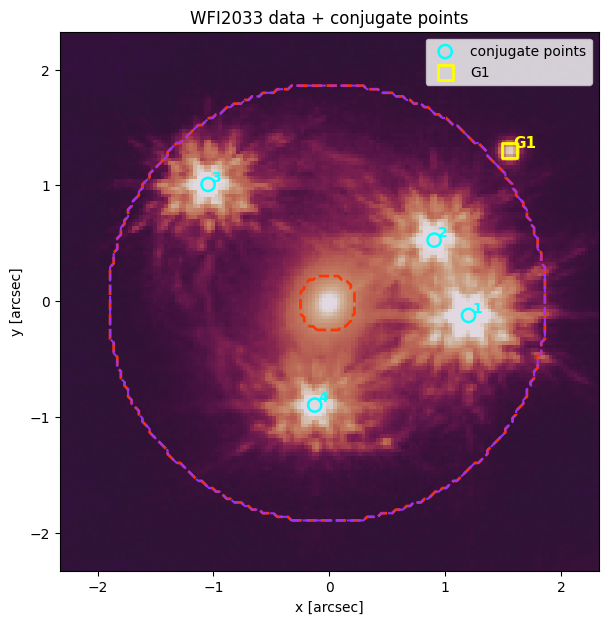

In [4]:
# Quick data visualization (same style as old JWST notebook)
plt.figure(figsize=(8, 7))
plt.imshow(
    np.array(data),
    origin='lower',
    cmap='twilight',
    extent=extent,
    norm=colors.SymLogNorm(linthresh=1, vmax=10.5, vmin=-10),
)
plt.contour(np.array(mask), levels=[0.5], colors='#ff3300', alpha=0.95, linewidths=2, linestyles='dashed', origin='lower', extent=extent)
plt.contour(np.array(mask_out), levels=[0.5], colors='#9933ff', alpha=0.95, linestyles='dashed', origin='lower', extent=extent)

# Overlay conjugate point positions
conj_np = np.array(conj_points, dtype=float)
plt.scatter(
    conj_np[:, 0],
    conj_np[:, 1],
    s=90,
    facecolors='none',
    edgecolors='cyan',
    linewidths=1.8,
    marker='o',
    label='conjugate points',
)
for i, (x, y) in enumerate(conj_np, start=1):
    plt.text(x + 0.03, y + 0.03, str(i), color='cyan', fontsize=10, weight='bold')

# Galaxy labels (for reference)
G1 = (1.556, 1.299)  # first galaxy
G2 = (2.145, -3.326)  # second galaxy

# Show only G1 in this panel
plt.scatter(
    [G1[0]],
    [G1[1]],
    s=120,
    facecolors='none',
    edgecolors='yellow',
    linewidths=2.0,
    marker='s',
    label='G1',
)
plt.text(G1[0] + 0.03, G1[1] + 0.03, 'G1', color='yellow', fontsize=11, weight='bold')

plt.title('WFI2033 data + conjugate points')
plt.xlabel('x [arcsec]')
plt.ylabel('y [arcsec]')
plt.legend(loc='upper right')
plt.show()


In [5]:
# Prior config block
MASS_PRIOR_PARAMETRIC = {
    'gamma_low': 1.95,
    'gamma_up': 2.05,
    'center_high': 0.5,
    'center_low': -0.5,
    'theta_low': 0.9,
    'theta_high': 1.1,
}

MASS_PRIOR_PIXELATED = {'theta_low': 0.9, 'theta_high': 1.1}

LENS_LIGHT_PRIOR_KWARGS = {
    'plate_name': 'Lens light',
    'param_name': 'lens',
    'n_gauss': N_gauss_light,
    'sigma_lims': sigma_lims_lens,
    'e_low': -0.2,
    'e_high': 0.2,
}

POINT_SOURCE_PRIOR = {
    'pos_sigma': 0.05,
    'pos_window': 0.2,
    'log10_amp_low': -3.0,
    'log10_amp_high': 4.5,
    'log10_amp_lens_low': -3.0,
    'log10_amp_lens_high': 4.5,
}

CONJUGATE_POINT_PRIOR = {
    'rate': {
        'parametric': 10000.0,
        'pixelated': 1000.0,
    },
}

RMS_PRIOR = {
    'low_factor': 0.5,
    'high_factor': 1.5,
}

SOURCE_GRID_PRIOR = {
    'plate_name': 'Source grid',
    'param_name': 'source_grid',
    'sigma_low': 1e-5,
    'sigma_high' : 10,
    'n_high': 100,
    'positive': True,
}

SIS_G1_PRIOR = {
    'theta_low': 0.0,
    'theta_high': 0.25,
}

G1_MASS_CENTER = (1.556, 1.299)

SIS_G2_PRIOR = {
    'theta_mean': 0.622,
    'theta_sigma': 0.062,
}

G2_MASS_CENTER = (2.145, -3.326)

FREEZE_LENS_LIGHT_STAGE12 = True

LENS_LIGHT_FIXED_SITES = {
    'A_lens': jnp.array([1.15726235, 1.04838995, 1.15480344, 1.11615108, 0.922152586, 0.661034498, 0.277563798, 0.0789498956, 0.318320424, 99827.8954, 99888.3492, 29182.449, 0.0246192691, 12431.8367, 3511.78388], dtype=jnp.float64),
    'sigma_lens': jnp.array([1.46440526e-05, 3.15317697e-05, 6.83588748e-05, 0.000146718135, 0.000312910197, 0.000681043204, 0.00144536132, 0.00314293558, 0.00675173335, 0.0215160602, 0.0357124894, 0.0815655295, 0.145234199, 0.217334657, 0.856545353], dtype=jnp.float64),
    'e_lens': jnp.array([[-0.00392185886, 0.00122141552, 0.00125899859, -0.00269499179, -0.00124647416, -0.00516785814, 0.00343531347, 5.49069825e-05, -0.00160050295, -0.0755041683, -0.0299303554, -0.0694932359, 0.00538240171, -0.0648152966, 0.0108477476], [0.000903011856, -0.000321619309, 0.00366244332, -0.00541012021, -0.00118452236, 0.00627432102, -0.00142715753, -0.000407847733, -0.000837431564, 0.00839814065, 0.0145447511, 0.109600637, -0.00152485785, 0.117473196, 0.142012114]], dtype=jnp.float64),
    'center_lens': jnp.array([[0.00014111314, 0.0280261817, -0.115948827, 0.00206028811, 0.154115203, -0.0450651895, -0.246230267, -0.00239715761, 0.164147533, -0.000112038495, -0.00113936454, 0.00209146665, -0.0222490563, -0.00280073383, 0.213231431], [0.0126216063, -0.00654801565, -0.0312773282, 0.00491649701, 0.141622351, -0.223678096, 0.16159306, 0.134290122, -0.159907695, -0.0131308102, -0.0113828286, -0.0115331623, -0.00697689385, -0.0127595285, -0.0130979537]], dtype=jnp.float64),
}

LENS_LIGHT_FIXED_PARAMS = LENS_LIGHT_FIXED_SITES | {
    'amp_lens': LENS_LIGHT_FIXED_SITES['A_lens'] * (LENS_LIGHT_FIXED_SITES['sigma_lens'] ** 2),
}



In [6]:
# Data-loading diagnostics removed by design.


In [7]:
from herculens.PointSourceModel.point_source_model import PointSourceModel

mass_model = MassModel(['EPL', 'SHEAR', 'SIS', 'SIS'])

lens_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

point_source_model = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model,
    image_plane=pixel_grid,
)

lens_image = LensImageExtension(
    pixel_grid,
    psf,
    noise_class=noise,
    lens_light_model_class=lens_light_model,
    lens_mass_model_class=mass_model,
    source_model_class=source_light_model,
    point_source_model_class=point_source_model,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale = source_grid_scale
)


In [8]:
npix = int(mask_out.sum())
N_HIGH_SOURCE_GRID = SOURCE_GRID_PRIOR['n_high']

def model(
    data,
    k_values=None,
    conj=True,
    provided_rms=False,
    pixelated=False,
    n_value=None,
    mass_prior_kwargs=None,
    psf_kernel=None,
    psf_kernel_super=None,
    enable_psf_corr=False,
):
    if mass_prior_kwargs is None:
        mass_prior_kwargs = {}
    mass_params = EPL_w_shear('Mass model', '1', **mass_prior_kwargs)
    mass_params = mass_params + SIS(
        'Mass model g1',
        'g1',
        origin=G1_MASS_CENTER,
        theta_low=SIS_G1_PRIOR['theta_low'],
        theta_high=SIS_G1_PRIOR['theta_high'],
    )
    mass_params = mass_params + SIS(
        'Mass model g2',
        'g2',
        origin=G2_MASS_CENTER,
        theta_mean=SIS_G2_PRIOR['theta_mean'],
        theta_sigma=SIS_G2_PRIOR['theta_sigma'],
    )
    lens_light = multi_gauss_light(**LENS_LIGHT_PRIOR_KWARGS)

    n_ps = conj_points.shape[0]
    ra_ps = numpyro.sample(
        'ra_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 0],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    dec_ps = numpyro.sample(
        'dec_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 1],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    log10_amp_ps = numpyro.sample(
        'log10_amp_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_low'],
            POINT_SOURCE_PRIOR['log10_amp_high'],
        ).expand([n_ps]),
    )

    amp_quasar_ps = jnp.power(10.0, log10_amp_ps)
    kwargs_point_source = [{
        'ra': ra_ps,
        'dec': dec_ps,
        'amp': amp_quasar_ps,
    }]

    lens_img = lens_image_pixel if pixelated else lens_image

    if conj:
        src_x_ps, src_y_ps = lens_img.MassModel.ray_shooting(ra_ps, dec_ps, mass_params)
        conj_points_model = jnp.stack([src_x_ps, src_y_ps], axis=1)
        conj_distance = reduced_distance_matrix(conj_points_model)
        nc = conj_distance.shape[0]
        rate_key = 'pixelated' if pixelated else 'parametric'
        conj_rate = CONJUGATE_POINT_PRIOR['rate'][rate_key]
        with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
            numpyro.sample('conjugate_points', dist.Exponential(conj_rate), obs=conj_distance)

    if pixelated:
        if k_values is None:
            raise ValueError('k_values is required when pixelated=True')
        source_light = [
            matern_power_spectrum(
                SOURCE_GRID_PRIOR['plate_name'],
                SOURCE_GRID_PRIOR['param_name'],
                k_values,
                n_high=SOURCE_GRID_PRIOR['n_high'],
                n_value=n_value,
                sigma_low=SOURCE_GRID_PRIOR['sigma_low'],
                sigma_high=SOURCE_GRID_PRIOR['sigma_high'],
                positive=SOURCE_GRID_PRIOR['positive'],
            )
        ]
    else:
        conj_points_model_for_center = lens_image.trace_conjugate_points(mass_params)
        source_center = jnp.mean(conj_points_model_for_center, axis=0)
        source_light = multi_gauss_light_center(
            'Source light',
            'source',
            N_gauss_source,
            sigma_lims,
            center_det=source_center,
        )

    psf_ref = jnp.asarray(psf_hst if psf_kernel is None else psf_kernel)
    psf_kernel_eff = psf_kernel
    psf_kernel_det = psf_ref
    corr_field = jnp.ones_like(psf_ref)

    if pixelated and enable_psf_corr:
        corr_shape = tuple(psf_ref.shape)
        log_psf_corr_center = numpyro.sample(
            "log_psf_corr_center",
            dist.Normal(
                0.0,
                PSF_CORR_PRIOR["sigma_log"],
            ).expand(corr_shape),
        )
        corr_field = build_psf_corr_factor_field(
            log_psf_corr_center,
            psf_ref.shape,
            log_clip=PSF_CORR_PRIOR["log_clip"],
        )
        psf_kernel_det = build_corrected_psf_kernel(
            psf_ref,
            log_psf_corr_center,
        )
        psf_kernel_eff = psf_kernel_det

    numpyro.deterministic('psf_corr_factor_field', corr_field)
    numpyro.deterministic('psf_kernel_corrected', psf_kernel_det)

    model_image = lens_img.model(
        kwargs_lens=mass_params,
        kwargs_source=source_light,
        kwargs_lens_light=lens_light,
        kwargs_point_source=kwargs_point_source,
        source_add=True,
        point_source_add=True,
        psf_kernel=psf_kernel_eff,
        psf_kernel_super=psf_kernel_super,
    )

    if provided_rms:
        model_std = rms_file
    else:
        background_rms_model = numpyro.sample(
            'RMS',
            dist.LogUniform(rms * RMS_PRIOR['low_factor'], rms * RMS_PRIOR['high_factor']),
        )
        model_var = lens_img.Noise.C_D_model(model_image, background_rms=background_rms_model)
        model_std = jnp.sqrt(model_var)

    model_image_masked_out = model_image[mask_out]
    model_std_masked_out = model_std[mask_out]

    numpyro.deterministic('model_image', model_image)

    with numpyro.plate(f'Data masked - [{npix}]', npix):
        numpyro.sample('obs', dist.Normal(model_image_masked_out, model_std_masked_out), obs=data[mask_out])

def params2kwargs(params, fixed_params={}, pixelated=False):
    params_full = params | fixed_params
    kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1') + params2kwargs_SIS(params_full, 'g1') + params2kwargs_SIS(params_full, 'g2')
    kwargs_lens_light = params2kwargs_multi_gauss_light(params_full, 'lens')
    kwargs_point_source = [{
        'ra': params_full['ra_ps'],
        'dec': params_full['dec_ps'],
        'amp': jnp.power(10.0, params_full['log10_amp_ps']),
    }]

    if pixelated:
        kwargs_source = [params2kwargs_power_spectrum(params_full, 'source_grid')]
    else:
        conj_points_model = lens_image.trace_conjugate_points(kwargs_lens)
        source_center = jnp.mean(conj_points_model, axis=0)
        n_source = params_full['amp_source'].shape[0]
        center_source = jnp.vstack([
            jnp.full((n_source,), source_center[0]),
            jnp.full((n_source,), source_center[1]),
        ])
        params_full = params_full | {'center_source': center_source}
        kwargs_source = params2kwargs_multi_gauss_light(params_full, 'source')

    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': kwargs_source,
        'kwargs_lens_light': kwargs_lens_light,
        'kwargs_point_source': kwargs_point_source,
    }

MODEL_STAGE12 = numpyro.handlers.condition(
    model,
    data=LENS_LIGHT_FIXED_SITES,
) if FREEZE_LENS_LIGHT_STAGE12 else model

def params2psf_kernel(params):
    log_psf_corr_center = params['log_psf_corr_center']
    return build_corrected_psf_kernel(psf_hst, log_psf_corr_center)

model_graph = numpyro.render_model(
    model,
    model_args=(data,),
    model_kwargs={
        'pixelated': False,
        'provided_rms': provided_rms,
        'mass_prior_kwargs': MASS_PRIOR_PARAMETRIC,
    },
    render_distributions=True,
)



100%|██████████| 10000/10000 [00:44<00:00, 226.49it/s, init loss: 1368266.9615, avg. loss [9501-10000]: 96699.8705]


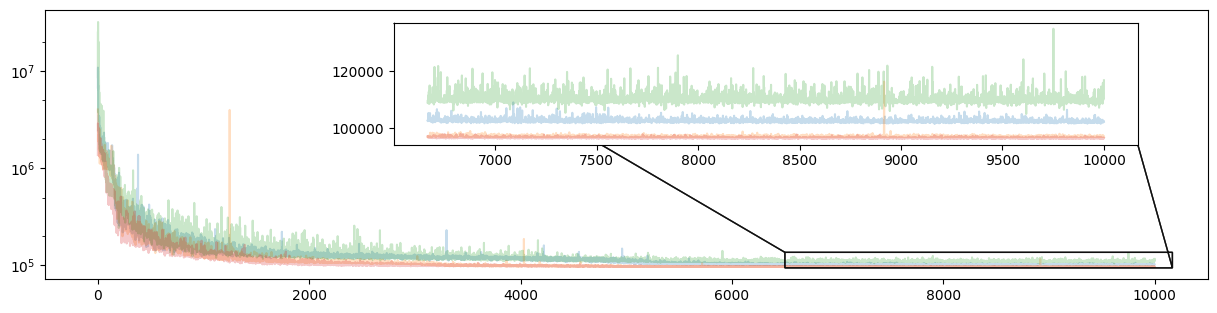

In [9]:
max_iterations = 10000
num_chains = 4
PARAMETRIC_SVI_KWARGS = {
    'conj': True,
    'pixelated': False,
    'n_value': None,
    'provided_rms': provided_rms,
    'mass_prior_kwargs': MASS_PRIOR_PARAMETRIC,
}

amp_ps_start = jnp.array([10120.25246224, 5648.26269992, 5112.50014416, 3735.28867656], dtype=jnp.float64)
init_values_parametric = {
    'log10_amp_ps': jnp.log10(amp_ps_start),
    # 'A_lens':jnp.array([1.12465451e+00, 8.19869998e-01, 3.42137514e-01, 8.57458596e-02,
    #     1.24464378e-01, 9.97932141e+04, 9.97950318e+04, 2.21679144e+04,
    #     7.85527204e+03, 2.86756266e+03]),
    # 'e_lens':jnp.array([[-0.00239425, -0.00354331, -0.00260818, -0.00163651, -0.00498165,
    #      -0.05040846, -0.04692338, -0.08225266, -0.03393363, -0.00074002],
    #     [ 0.0006679 , -0.00146487,  0.00045147, -0.00376748, -0.00105125,
    #      -0.0375857 ,  0.06289111,  0.10578636,  0.12659461,  0.17445311]]),
    # 'center_lens':jnp.array([[-8.37472111e-02,  2.65523673e-01,  4.16968721e-01,
    #       6.75988629e-02, -5.49727690e-02, -2.19454704e-03,
    #      -1.59550227e-04,  1.05397949e-03, -2.67173672e-03,
    #       2.48827700e-01],
    #     [ 4.02086243e-02, -1.15835970e-01,  2.55345431e-01,
    #      -1.41492656e-01, -2.94682930e-01, -1.56167803e-02,
    #      -1.16483716e-02, -1.47340376e-02, -5.23077155e-03,
    #       7.68036455e-03]]),
    # 'sigma_lens':jnp.array([1.65261040e-04, 4.45904047e-04, 1.17343614e-03, 3.14715269e-03,
    #     8.41874386e-03, 2.60697629e-02, 3.82953612e-02, 1.13147567e-01,
    #     2.76466227e-01, 9.15631667e-01]),
}
init_fun = init_to_value_or_defer(values=init_values_parametric)
scheduler = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim = optax.adabelief(learning_rate=scheduler)
loss = infer.Trace_ELBO(num_particles=1)

rng_key = jax.random.PRNGKey(420)
rng_key, rng_key_ = jax.random.split(rng_key)
svi_keys = jax.random.split(rng_key_, num_chains)

param_results_list = []
param_guides = []
for i in range(num_chains):
    guide_i = autoguide.AutoLowRankMultivariateNormal(model, init_loc_fn=init_fun)
    svi_i = infer.SVI(model, guide_i, optim, loss)
    result_i = svi_i.run(
        svi_keys[i],
        max_iterations,
        data,
        **PARAMETRIC_SVI_KWARGS,
        progress_bar=True,
        stable_update=True,
    )
    param_guides.append(guide_i)
    param_results_list.append(result_i)


def _stack_or_none(*xs):
    first = xs[0]
    return None if first is None else jnp.stack(xs)


multi_svi_results = jax.tree.map(_stack_or_none, *param_results_list)
guide = param_guides[0]
multi_svi_median = guide.median(multi_svi_results.params)

multi_svi_median_herc = median_params2kwargs(params2kwargs, multi_svi_median, jnp.arange(num_chains))

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_results.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)


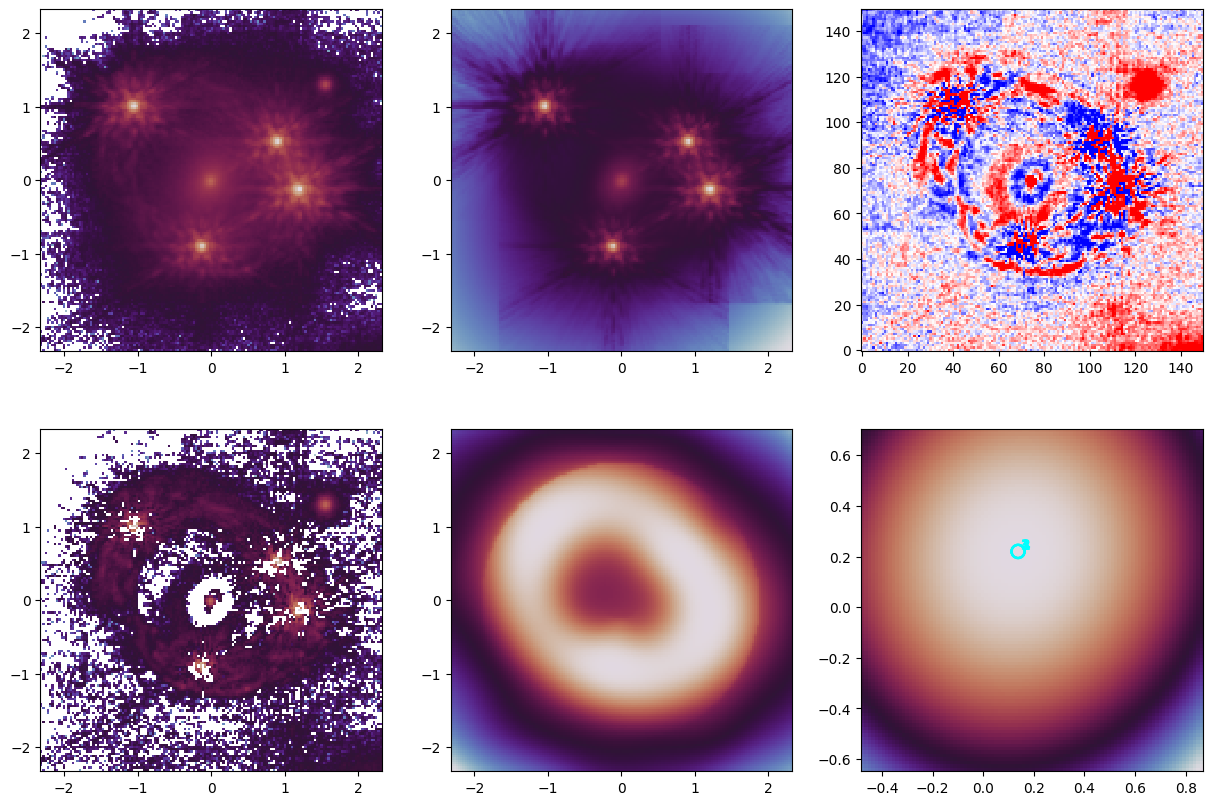

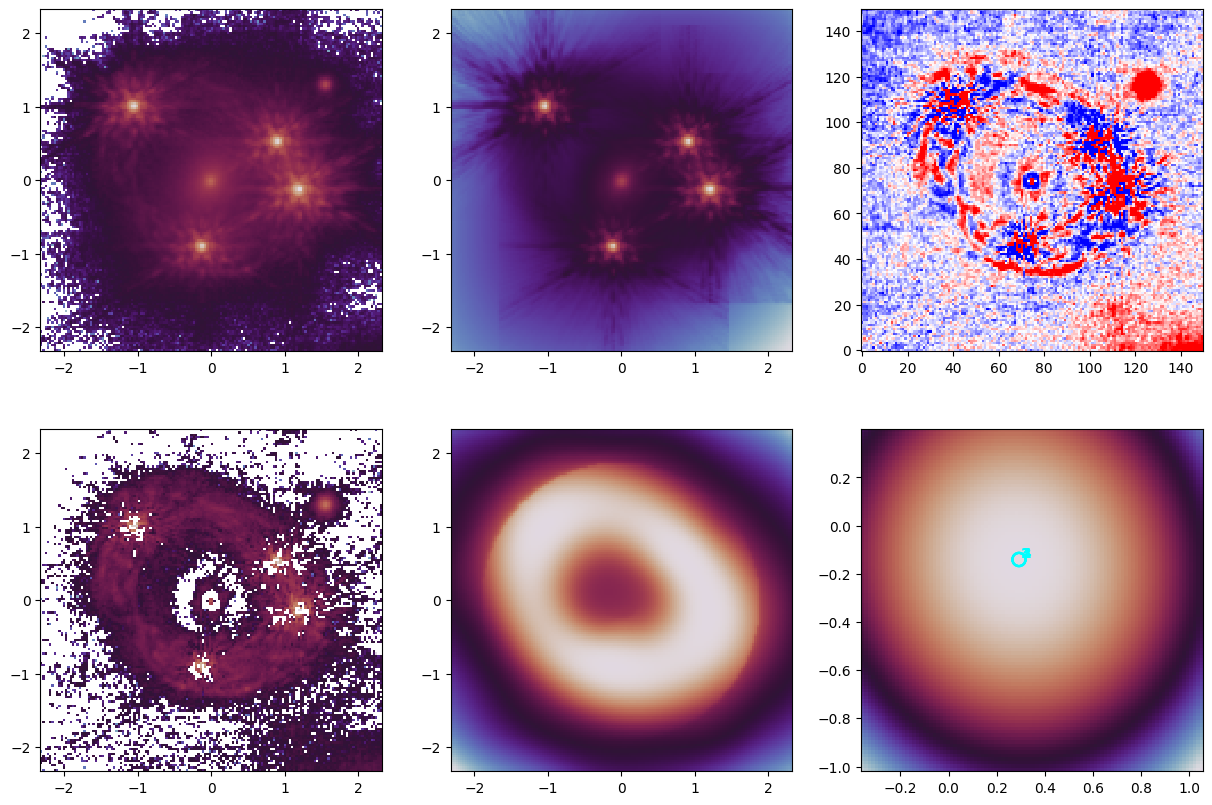

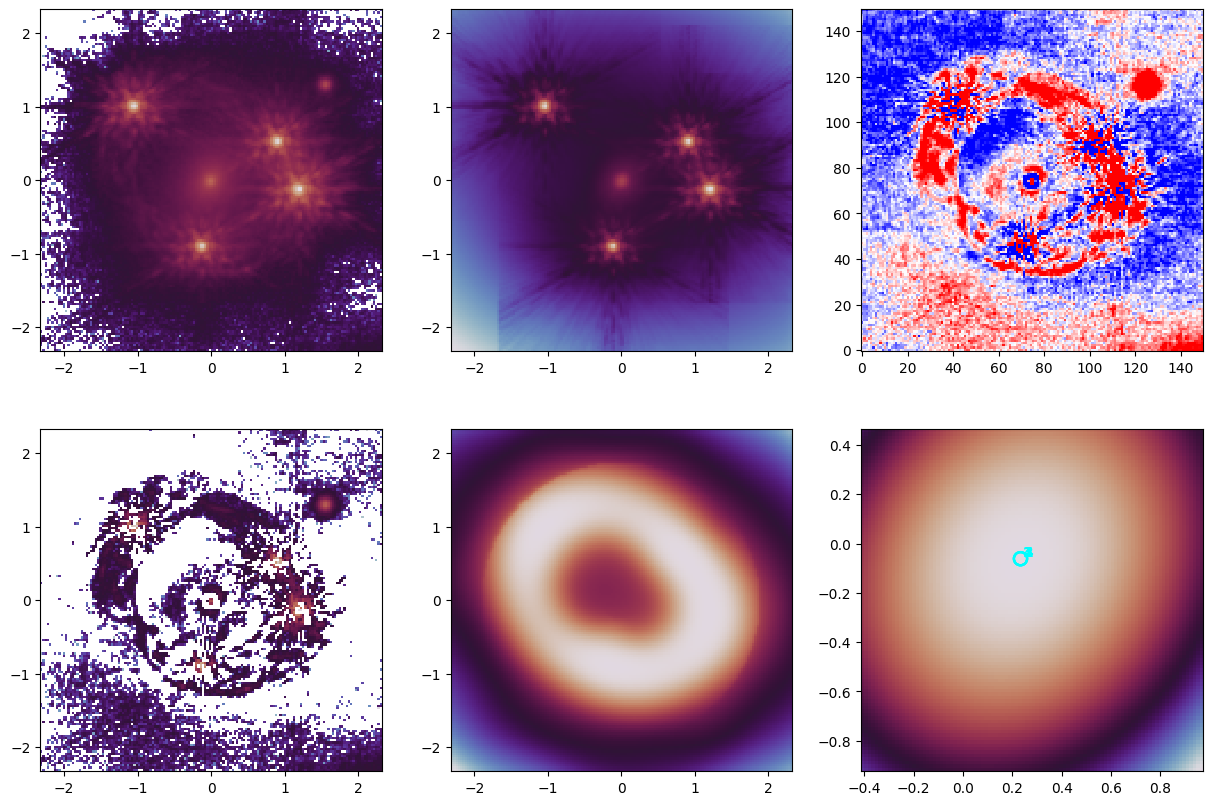

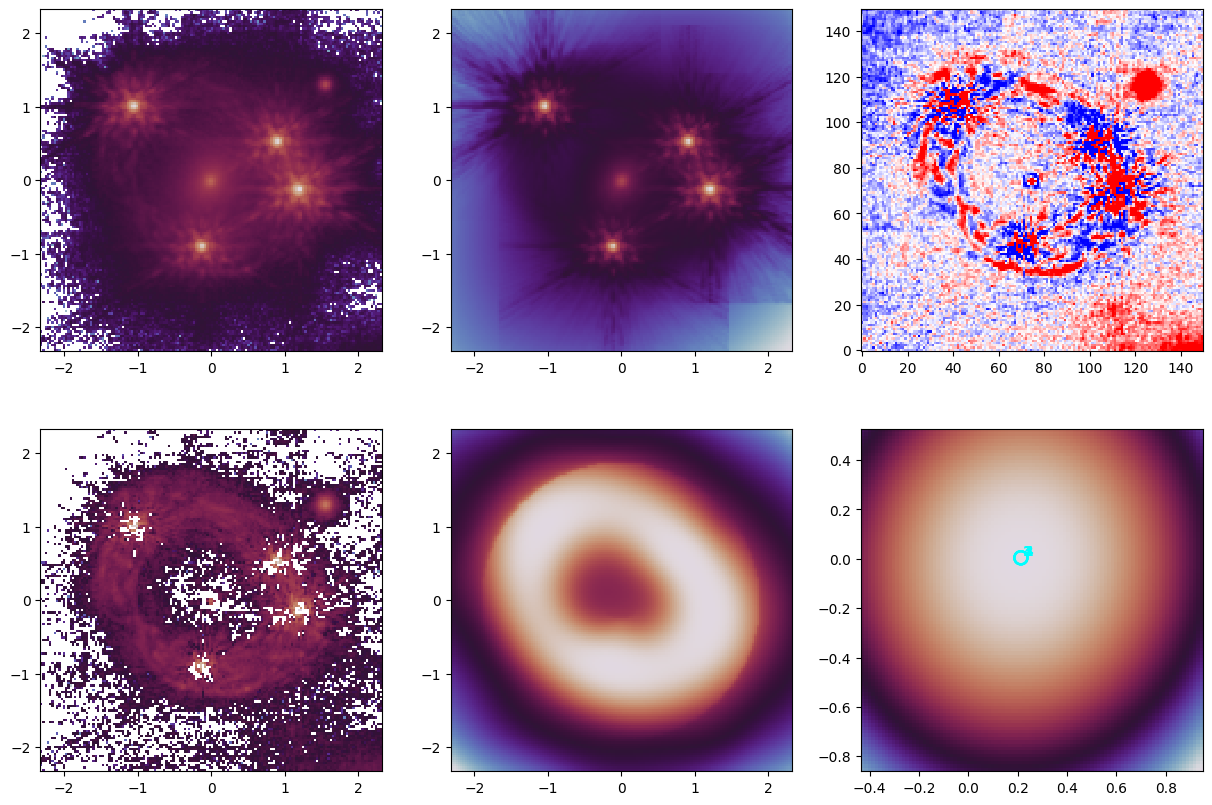

In [10]:
from lens_images_extension import pixelize_plane as pixelize_plane_single

for i in range(4):
    kwargs_i = get_value_from_index(multi_svi_median_herc, i)

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(data, norm='log', cmap='twilight', extent=extent, origin='lower')

    plt.subplot(2, 3, 2)
    image_model = lens_image.model(**kwargs_i, source_add=True)
    plt.imshow(image_model, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 3)
    plt.imshow((data - image_model) / rms_file, cmap='bwr', vmax=3, vmin=-3)

    plt.subplot(2, 3, 4)
    lens_light = lens_image.model(**kwargs_i, source_add=False)
    plt.imshow(data - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 5)
    plt.imshow(image_model - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 6)
    source, source_extent = pixelize_plane_single(
        lens_image,
        kwargs_i,
        100,
    )
    plt.imshow(source, extent=source_extent, norm='log', cmap='twilight')
    src_x, src_y = trace_current_agn_to_source(lens_image, kwargs_i)
    plt.scatter(np.array(src_x), np.array(src_y), s=90, facecolors='none', edgecolors='cyan', linewidths=1.6, marker='o')
    for j, (sx, sy) in enumerate(zip(np.array(src_x), np.array(src_y)), start=1):
        plt.text(sx + 0.01, sy + 0.01, str(j), color='cyan', fontsize=10, weight='bold')


In [11]:
best_pix_sizes = np.array([
    get_best_pixel_size(
        lens_image,
        get_value_from_index(multi_svi_median_herc, i),
        source_grid_scale
    ) for i in range(num_chains)
])
pixel_grid_shape = np.median(best_pix_sizes).astype(int)*1
# pixel_grid_shape = 50
print(pixel_grid_shape)

75


In [12]:
vars_mass = ['theta_E_1', 'theta_E_g1', 'theta_E_g2', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens', 'e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_point_source = ['ra_ps', 'dec_ps', 'log10_amp_ps']
vars_other = []

svi_samples = guide.sample_posterior(rng_key_, multi_svi_results.params, sample_shape=(1000,))
svi_samples_chains = jax.tree.map(lambda x: jnp.swapaxes(x, 0, 1), svi_samples)
svi_samples_chains = jax.device_get(svi_samples_chains)
multi_svi_guide_sample = az.from_dict(svi_samples_chains)

k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

orig_source_list = []
for idx in range(num_chains):
    image_i, _ = pixelize_plane_single(
        lens_image,
        get_value_from_index(multi_svi_median_herc, idx),
        pixel_grid_shape,
        source_grid_scale=source_grid_scale,
    )
    orig_source_list.append(image_i)
orig_source = jnp.stack(orig_source_list, axis=0)
ps_keys = jax.random.split(rng_key_, num_chains)
from herculens_import_main import source_power_spectrum
ps_fits = source_power_spectrum(orig_source, ps_keys, None, True)

keys_for_pixel_init = vars_lens_light + vars_mass + vars_point_source + vars_other
multi_svi_median_pixelated = {k: multi_svi_median[k] for k in keys_for_pixel_init if k in multi_svi_median} | ps_fits




In [13]:
k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

from herculens.PointSourceModel.point_source_model import PointSourceModel

mass_model_pixel = MassModel(['EPL', 'SHEAR', 'SIS', 'SIS'])
lens_light_model_pixel = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model_pixel = LightModel(
    ['PIXELATED',],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape}
)

pixel_grid_pixel = deepcopy(pixel_grid)
psf_pixel = deepcopy(psf)

point_source_model_pixel = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_pixel,
    image_plane=pixel_grid_pixel,
)

lens_image_pixel = LensImageExtension(
    pixel_grid_pixel,
    psf_pixel,
    noise_class=noise,
    lens_light_model_class=lens_light_model_pixel,
    lens_mass_model_class=mass_model_pixel,
    source_model_class=source_light_model_pixel,
    point_source_model_class=point_source_model_pixel,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)



In [14]:
npix = int(mask_out.sum())
N_HIGH_SOURCE_GRID = 1000

PIXELATED_BASE_KWARGS = {
    'k_values': k_grid.k,
    'conj': True,
    'pixelated': True,
    'n_value': None,
    'provided_rms': provided_rms,
    'mass_prior_kwargs': MASS_PRIOR_PIXELATED,
}
PIXELATED_STAGE1_KWARGS = PIXELATED_BASE_KWARGS | {
    'enable_psf_corr': False,
}
PIXELATED_STAGE2_KWARGS = PIXELATED_BASE_KWARGS | {
    'enable_psf_corr': True,
}
PIXELATED_STAGE3_KWARGS = PIXELATED_BASE_KWARGS | {
    'enable_psf_corr': True,
}
HMC_RUN_KWARGS = PIXELATED_BASE_KWARGS | {
    'conj': False,
    'enable_psf_corr': True,
}

model_graph = numpyro.render_model(
    model,
    model_args=(data,),
    model_kwargs=PIXELATED_STAGE1_KWARGS,
    render_distributions=True,
)


100%|██████████| 10000/10000 [00:38<00:00, 259.15it/s, init loss: 130549.2768, avg. loss [9501-10000]: 78182.5184]


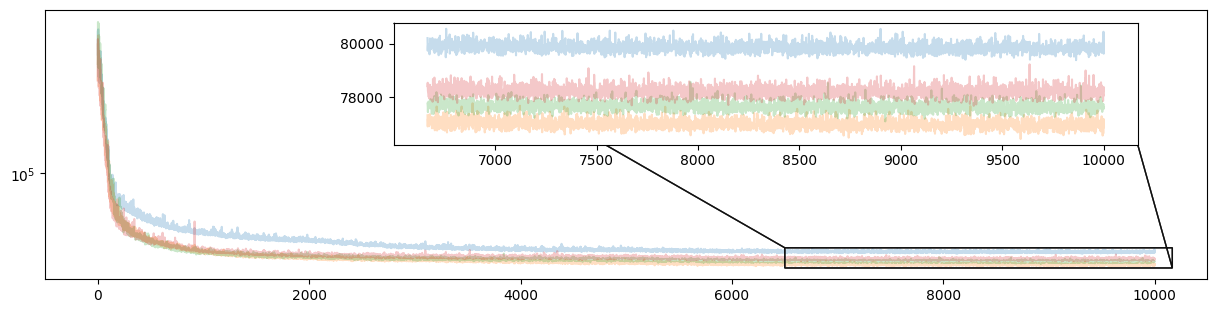

In [15]:
max_iterations = 10000
num_chains = 4

scheduler_stage1 = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim_stage1 = optax.adabelief(learning_rate=scheduler_stage1)
loss_stage1 = infer.TraceMeanField_ELBO()

svi_keys = jax.random.split(rng_key_, num_chains)
stage1_results_list = []
stage1_guides = []

for i in range(num_chains):
    init_values_stage1_i = get_value_from_index(multi_svi_median_pixelated, i) | LENS_LIGHT_FIXED_PARAMS
    init_fun_stage1_i = init_to_value_or_defer(values=init_values_stage1_i)
    guide_stage1_i = autoguide.AutoDiagonalNormal(MODEL_STAGE12, init_loc_fn=init_fun_stage1_i, init_scale=0.01)
    svi_stage1_i = infer.SVI(MODEL_STAGE12, guide_stage1_i, optim_stage1, loss_stage1)
    result_i = svi_stage1_i.run(
        svi_keys[i],
        max_iterations,
        data,
        **PIXELATED_STAGE1_KWARGS,
        progress_bar=True,
        stable_update=True,
    )
    stage1_guides.append(guide_stage1_i)
    stage1_results_list.append(result_i)

def _stack_or_none(*xs):
    if xs[0] is None:
        return None
    return jnp.stack(xs)

multi_svi_pixel_results_stage1 = jax.tree.map(_stack_or_none, *stage1_results_list)
guide_pixel_stage1 = stage1_guides[0]
multi_svi_pixel_median_stage1 = guide_pixel_stage1.median(multi_svi_pixel_results_stage1.params)
multi_svi_pixel_median_herc_stage1 = median_params2kwargs(
    lambda p, fixed_params=LENS_LIGHT_FIXED_PARAMS: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage1,
    jnp.arange(num_chains),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_pixel_results_stage1.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

#383 source pixels: 6120s


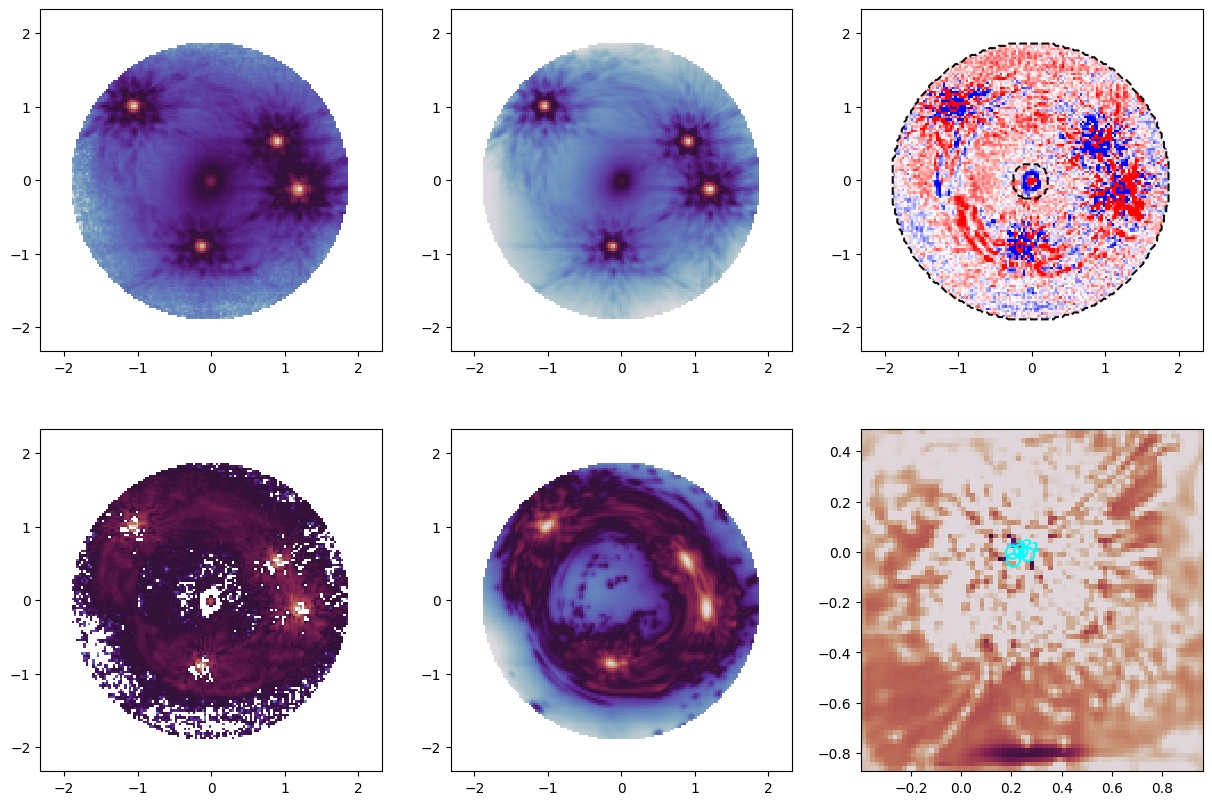

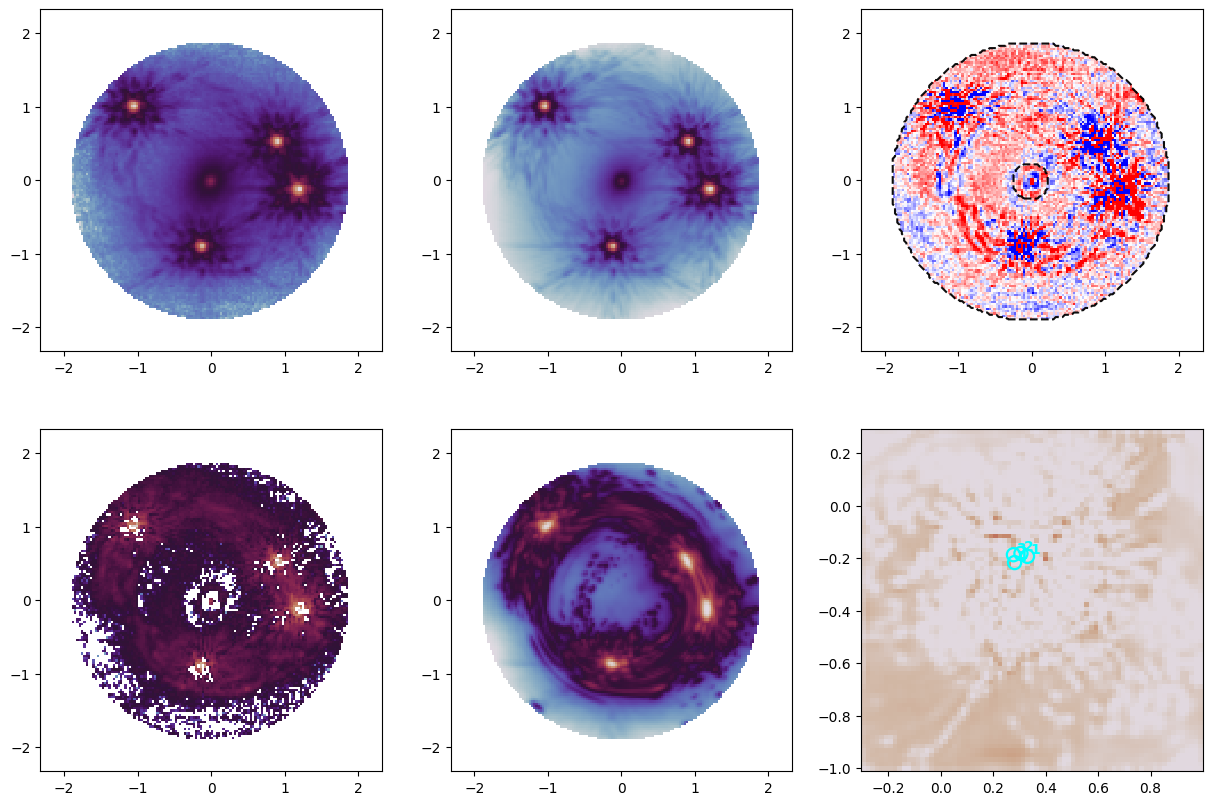

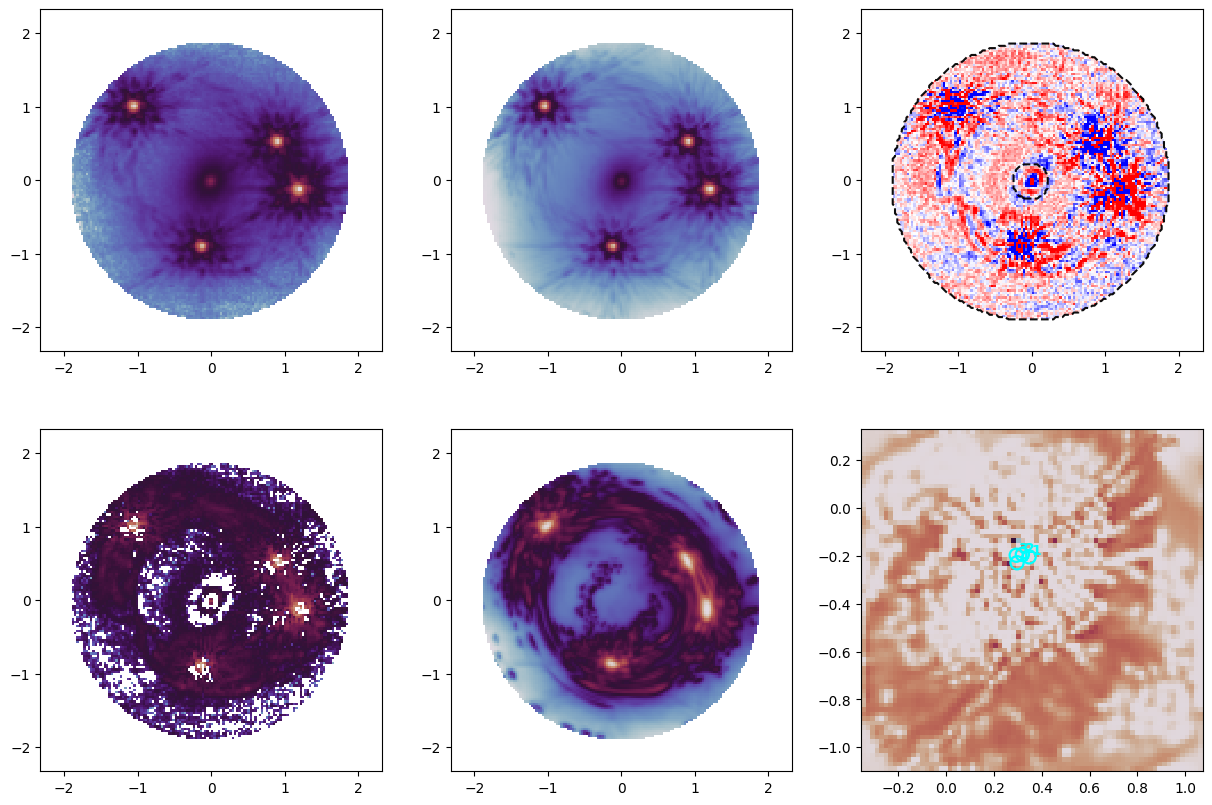

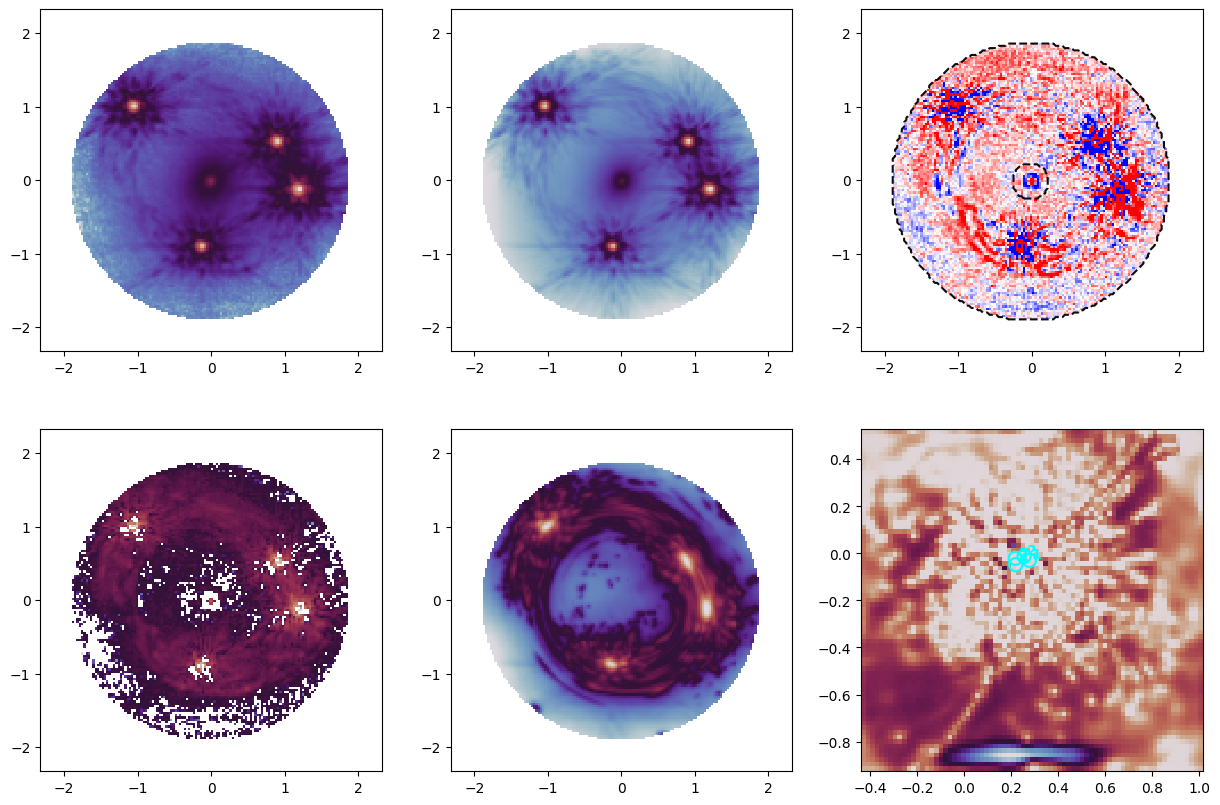

In [16]:
from lens_images_extension import pixelize_plane as pixelize_plane_single

for i in range(4):
    kwargs_i = get_value_from_index(multi_svi_pixel_median_herc_stage1, i)

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(np.ma.array(data, mask=~mask_out), norm='log', cmap='twilight', extent=extent, origin='lower')

    plt.subplot(2, 3, 2)
    image_model = lens_image_pixel.model(**kwargs_i, source_add=True)
    plt.imshow(np.ma.array(image_model, mask=~mask_out), norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 3)
    plt.imshow(np.ma.array((data - image_model) / rms_file, mask=~mask_out), cmap='bwr', vmax=3, vmin=-3, extent=extent)
    plt.contour(mask, levels=[0.5], colors='black', alpha=0.95, linewidth=2, linestyles='dashed', origin='lower', extent=extent)

    plt.subplot(2, 3, 4)
    lens_light = lens_image_pixel.model(**kwargs_i, source_add=False)
    plt.imshow(np.ma.array(data - lens_light, mask=~mask_out), norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 5)
    plt.imshow(np.ma.array(image_model - lens_light, mask=~mask_out), norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 6)
    source, source_extent = pixelize_plane_single(
        lens_image_pixel,
        kwargs_i,
        pixel_grid_shape,
    )
    plt.imshow(source, extent=source_extent, norm='log', cmap='twilight')
    src_x, src_y = trace_current_agn_to_source(lens_image_pixel, kwargs_i)
    plt.scatter(np.array(src_x), np.array(src_y), s=90, facecolors='none', edgecolors='cyan', linewidths=1.6, marker='o')
    for j, (sx, sy) in enumerate(zip(np.array(src_x), np.array(src_y)), start=1):
        plt.text(sx + 0.01, sy + 0.01, str(j), color='cyan', fontsize=10, weight='bold')


100%|██████████| 20000/20000 [01:09<00:00, 286.51it/s, init loss: 150254.4935, avg. loss [19001-20000]: 19829.3515]


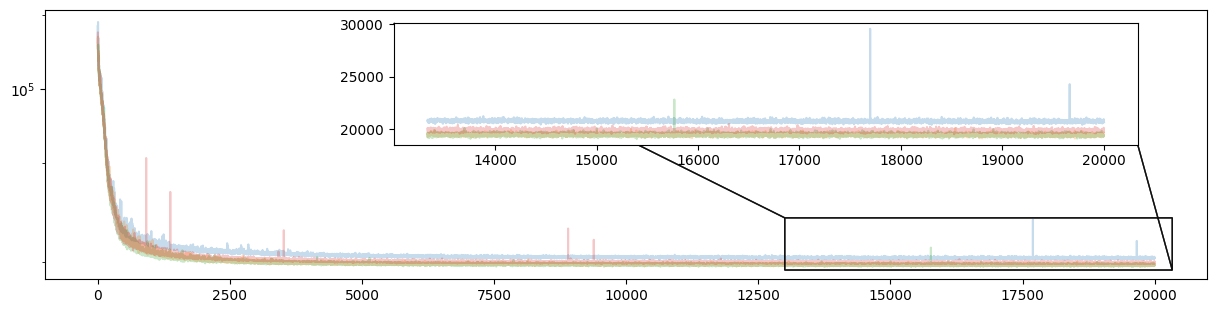

In [17]:
max_iterations = 20000
num_chains = 4

scheduler_stage2 = optax.exponential_decay(
    init_value=5e-3,
    transition_steps=200,
    decay_rate=0.99,
)
optim_stage2 = optax.adabelief(learning_rate=scheduler_stage2)
loss_stage2 = infer.TraceMeanField_ELBO()

svi_keys = jax.random.split(rng_key_, num_chains)
stage2_results_list = []
stage2_guides = []

for i in range(num_chains):
    init_values_stage2_i = get_value_from_index(multi_svi_pixel_median_stage1, i) | {
        'log_psf_corr_center': jnp.zeros(psf_hst.shape),
    } | LENS_LIGHT_FIXED_PARAMS
    init_fun_stage2_i = init_to_value_or_defer(values=init_values_stage2_i)
    guide_stage2_i = autoguide.AutoDiagonalNormal(MODEL_STAGE12, init_loc_fn=init_fun_stage2_i, init_scale=0.01)
    svi_stage2_i = infer.SVI(MODEL_STAGE12, guide_stage2_i, optim_stage2, loss_stage2)
    result_i = svi_stage2_i.run(
        svi_keys[i],
        max_iterations,
        data,
        **PIXELATED_STAGE2_KWARGS,
        psf_kernel=psf_hst,
        progress_bar=True,
        stable_update=True,
    )
    stage2_guides.append(guide_stage2_i)
    stage2_results_list.append(result_i)

def _stack_or_none(*xs):
    if xs[0] is None:
        return None
    return jnp.stack(xs)

multi_svi_pixel_results_stage2 = jax.tree.map(_stack_or_none, *stage2_results_list)
guide_pixel_stage2 = stage2_guides[0]
multi_svi_pixel_median_stage2 = guide_pixel_stage2.median(multi_svi_pixel_results_stage2.params)
multi_svi_pixel_median_herc_stage2 = median_params2kwargs(
    lambda p, fixed_params=LENS_LIGHT_FIXED_PARAMS: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage2,
    jnp.arange(num_chains),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_pixel_results_stage2.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)


In [18]:
# Stage2b removed for now.
# Stage2 outputs are used directly in downstream blocks.


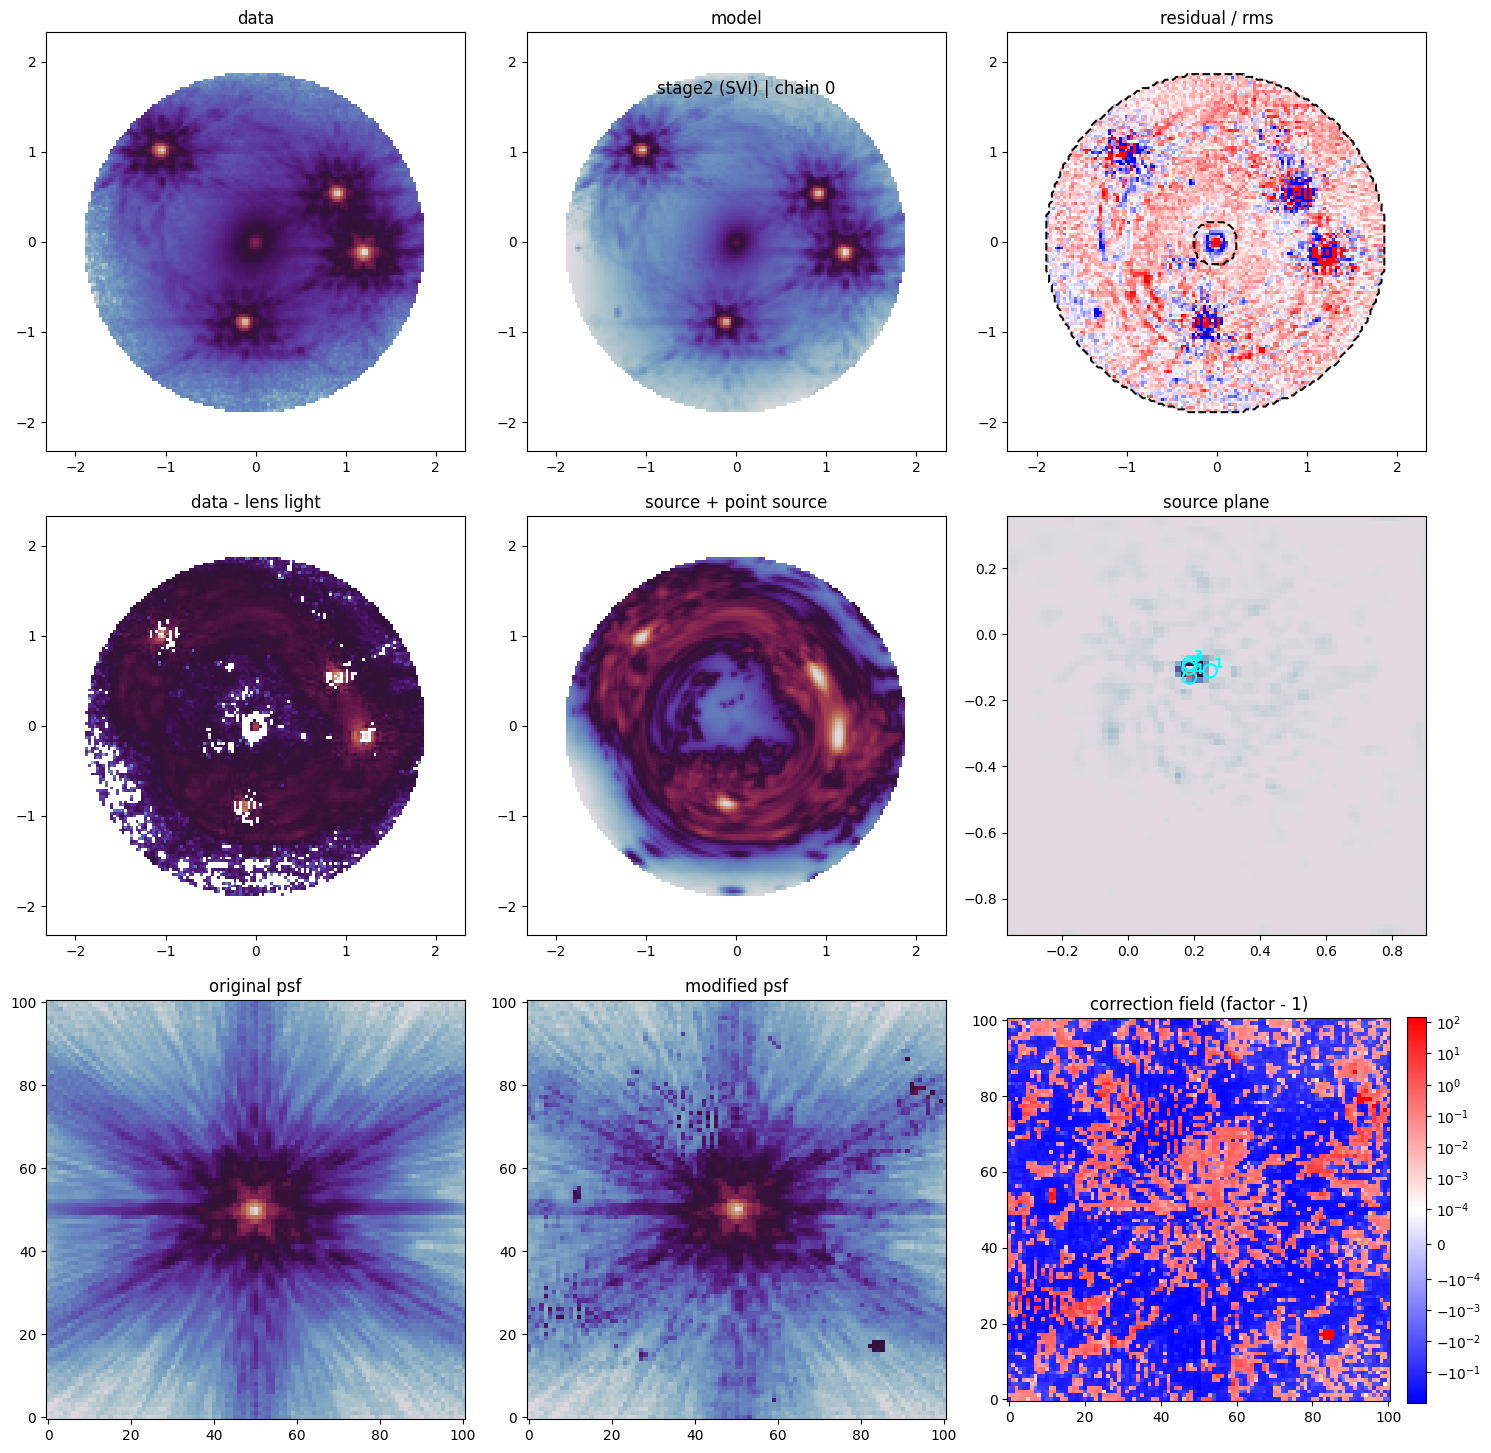

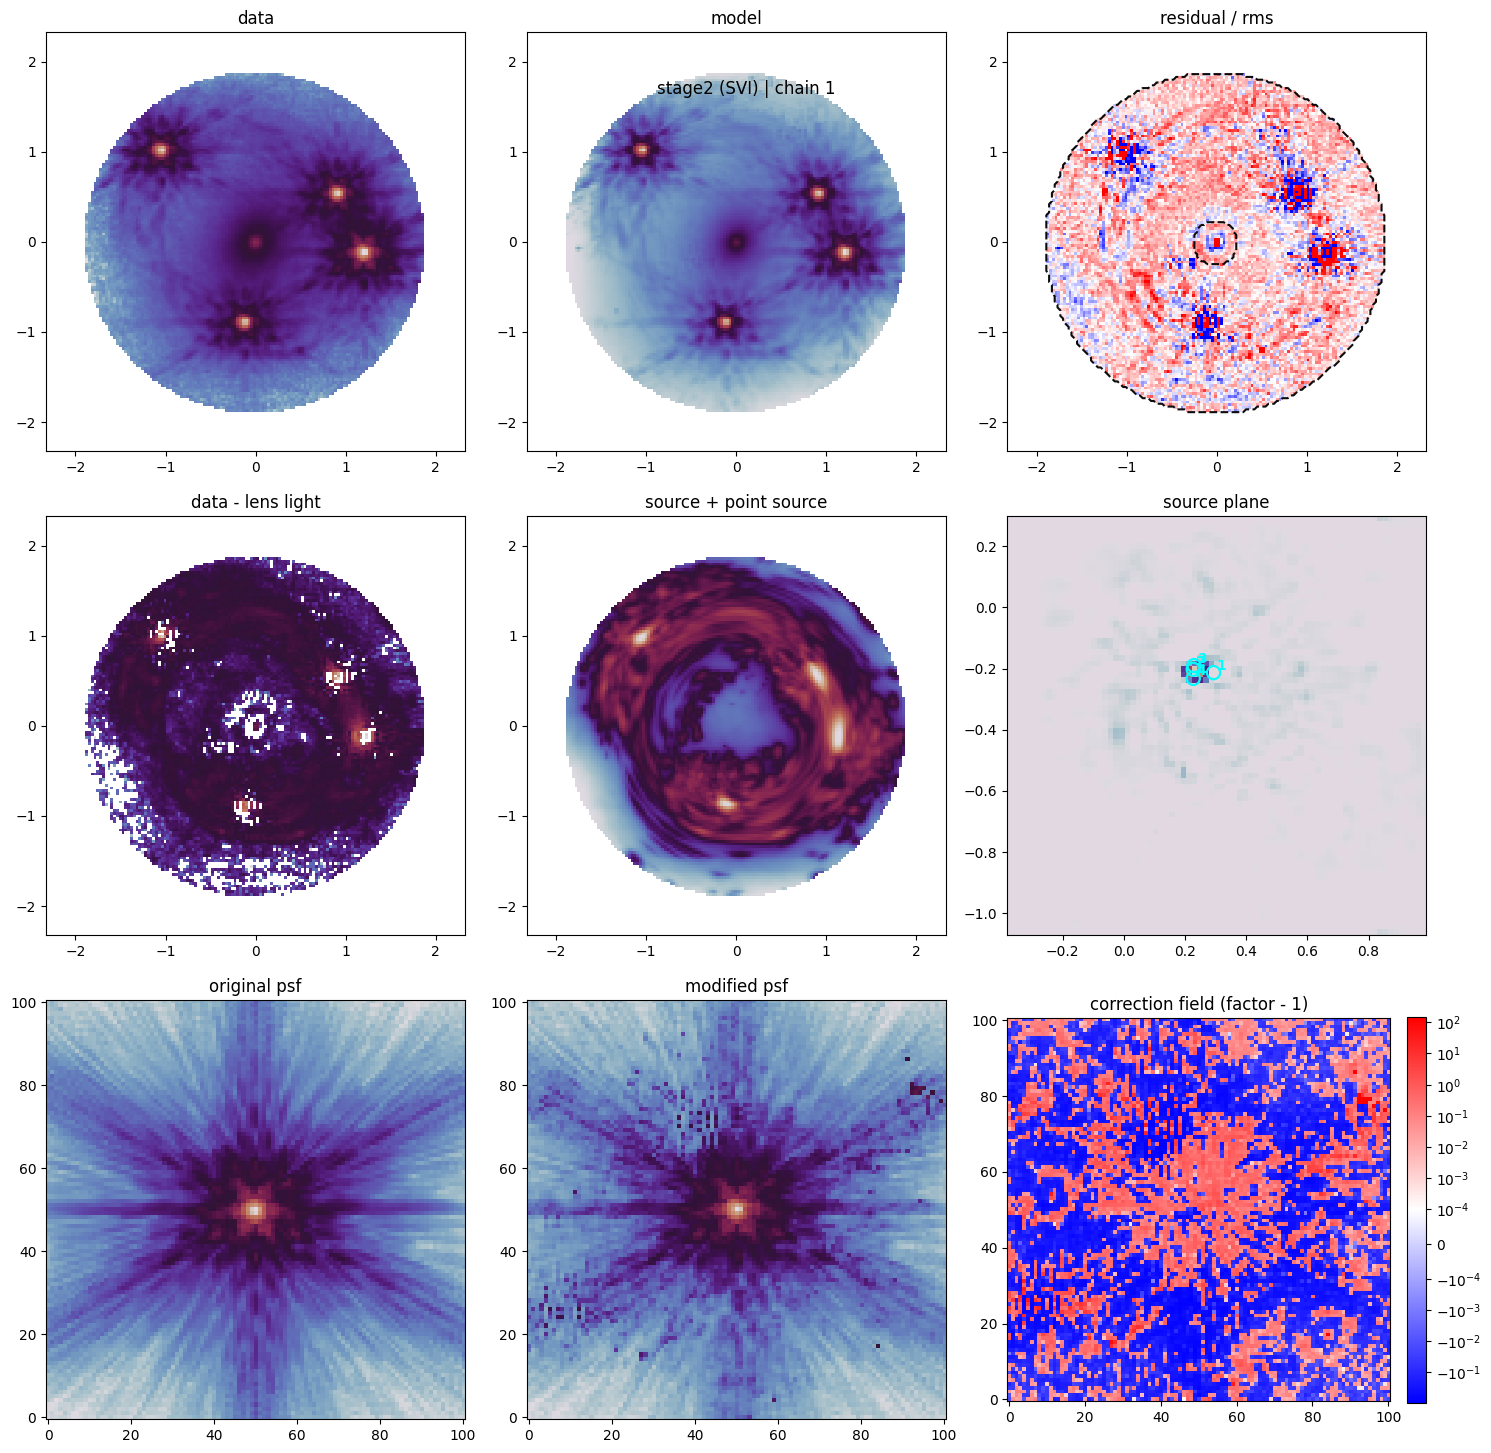

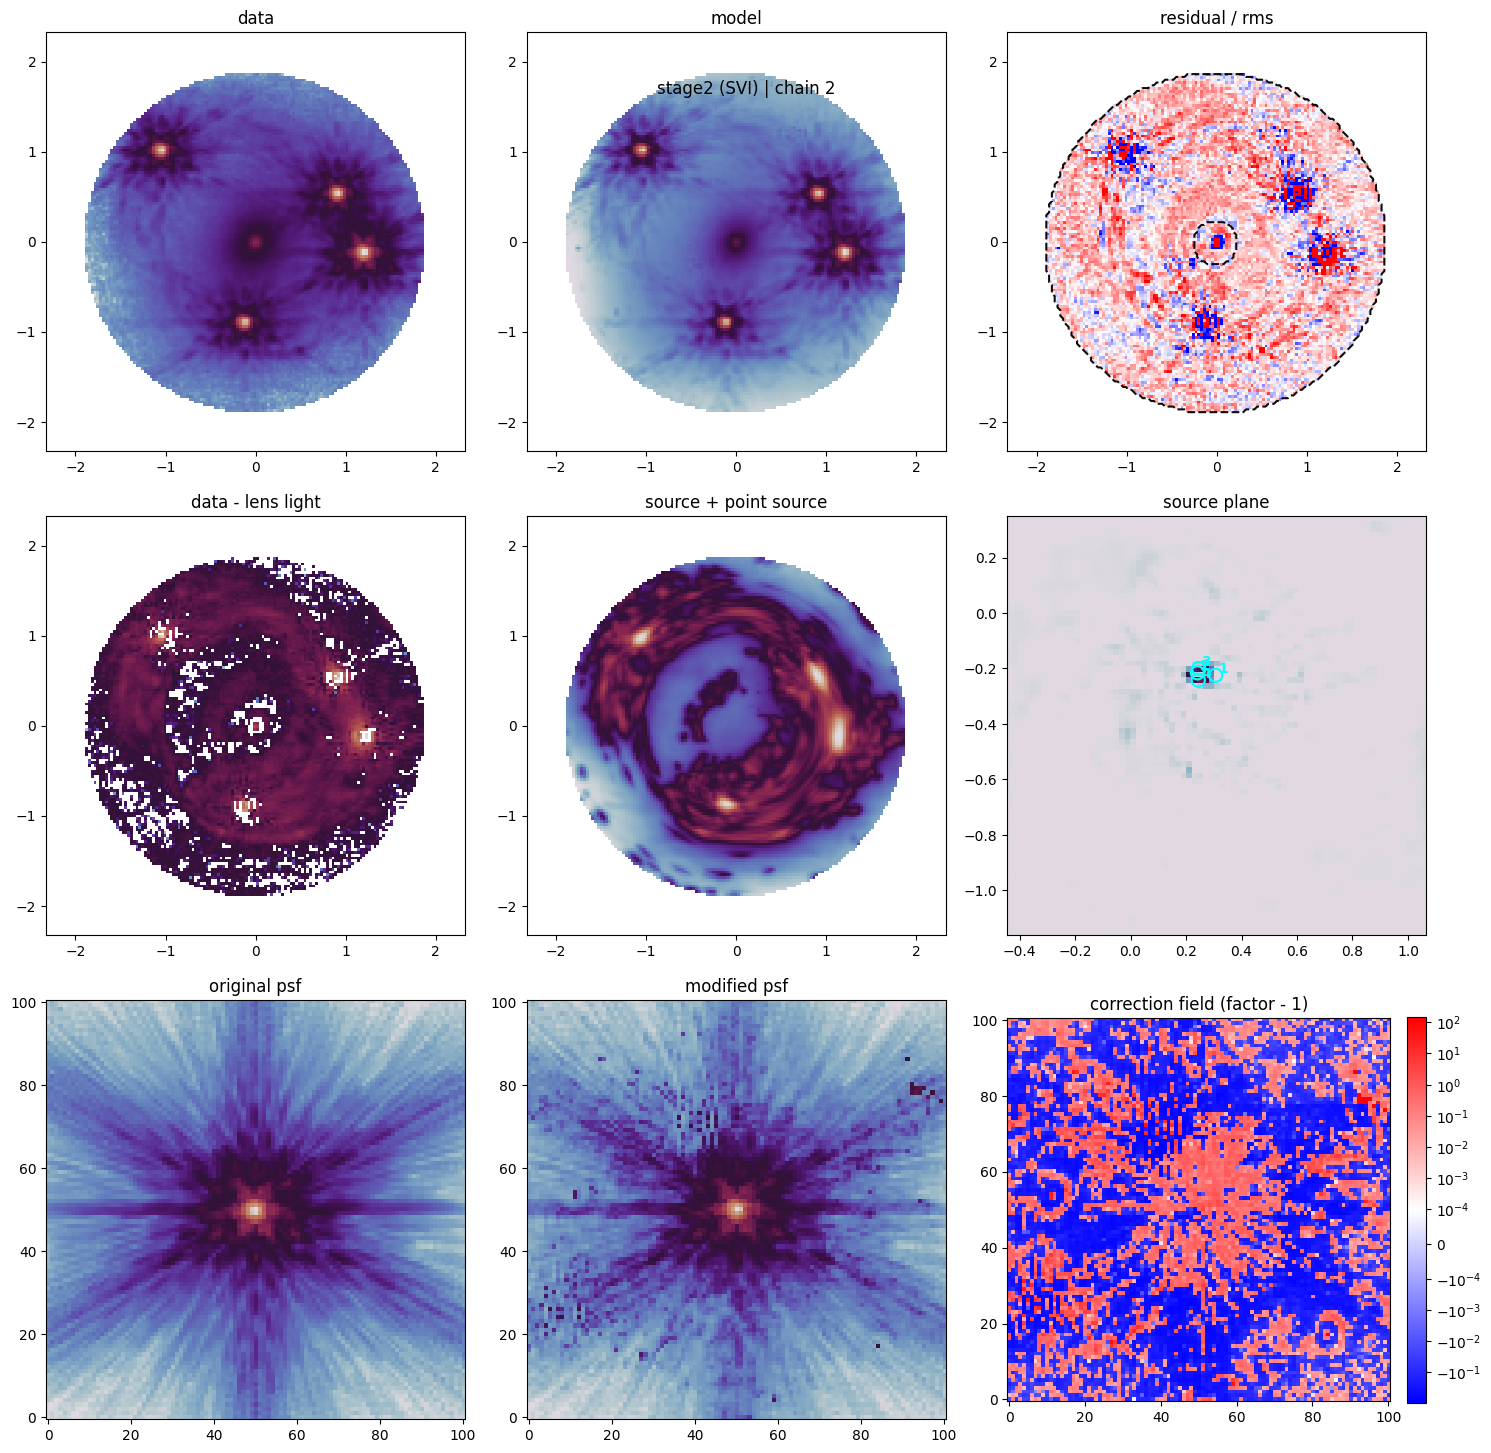

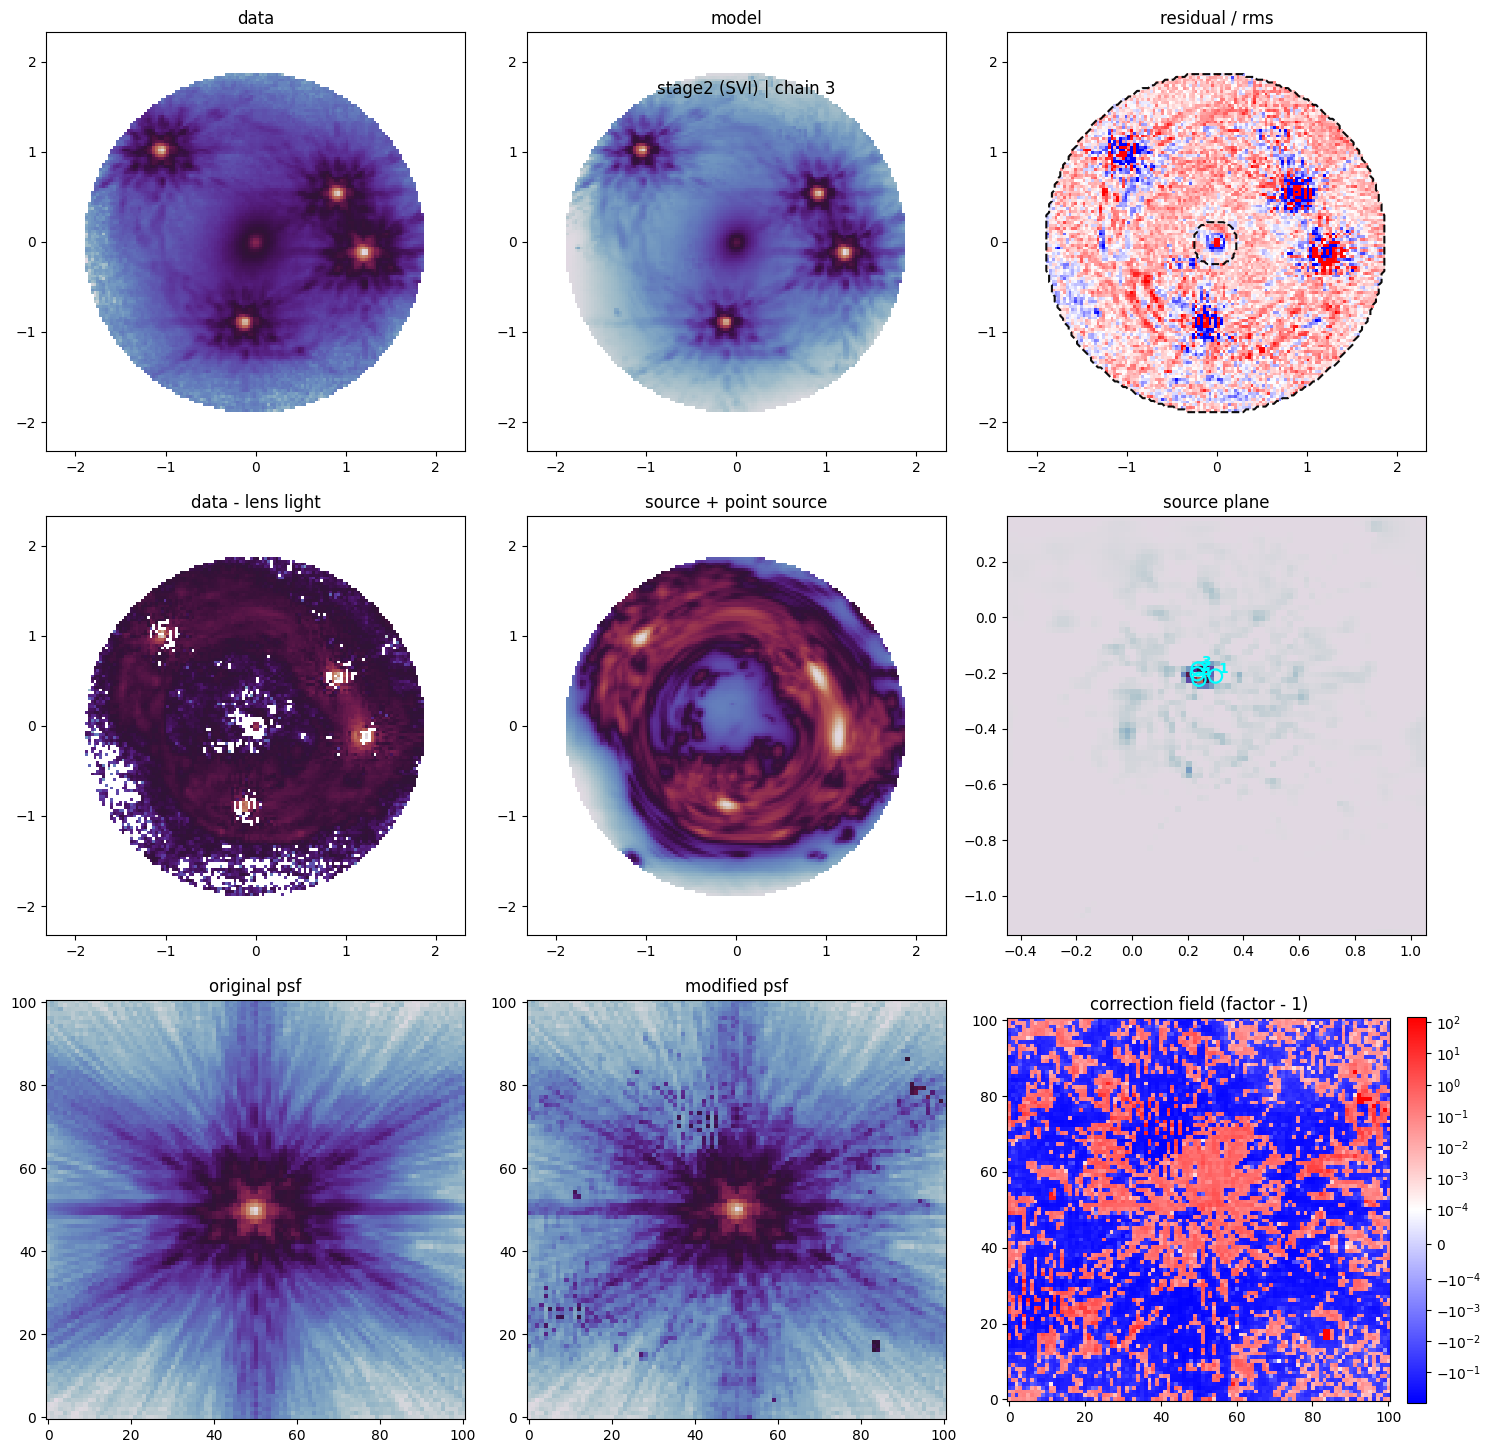

In [19]:
from lens_images_extension import pixelize_plane as pixelize_plane_single

def get_stage2_deterministics_from_median(params_all):
    psf_kernel_all = []
    corr_field_all = []
    for i in range(num_chains):
        params_i = get_value_from_index(params_all, i)
        trace_i = numpyro.handlers.trace(
            numpyro.handlers.substitute(
                numpyro.handlers.seed(model, jax.random.PRNGKey(1000 + i)),
                data=params_i,
            )
        ).get_trace(
            data,
            **PIXELATED_STAGE2_KWARGS,
            psf_kernel=psf_hst,
        )
        psf_kernel_all.append(trace_i['psf_kernel_corrected']['value'])
        corr_field_all.append(trace_i['psf_corr_factor_field']['value'])
    return jnp.stack(psf_kernel_all), jnp.stack(corr_field_all)

def plot_stage2_result_set(kwargs_all, psf_kernel_all, corr_field_all, stage_label):
    for i in range(num_chains):
        kwargs_i = get_value_from_index(kwargs_all, i)
        psf_kernel_i = get_value_from_index(psf_kernel_all, i)
        corr_field_i = get_value_from_index(corr_field_all, i)

        plt.figure(figsize=(15, 15))
        plt.suptitle(f'{stage_label} | chain {i}', y=0.92)

        plt.subplot(3, 3, 1)
        plt.imshow(np.ma.array(data, mask=~mask_out), norm='log', cmap='twilight', extent=extent, origin='lower')
        plt.title('data')

        plt.subplot(3, 3, 2)
        image_model = lens_image_pixel.model(
            **kwargs_i,
            source_add=True,
            point_source_add=True,
            psf_kernel=psf_kernel_i,
        )
        plt.imshow(np.ma.array(image_model, mask=~mask_out), norm='log', cmap='twilight', extent=extent)
        plt.title('model')

        plt.subplot(3, 3, 3)
        plt.imshow(np.ma.array((data - image_model) / rms_file, mask=~mask_out), cmap='bwr', vmax=3, vmin=-3, extent=extent)
        plt.contour(mask, levels=[0.5], colors='black', alpha=0.95, linewidth=2, linestyles='dashed', origin='lower', extent=extent)
        plt.title('residual / rms')

        lens_light_only = lens_image_pixel.model(
            **kwargs_i,
            source_add=False,
            point_source_add=True,
            psf_kernel=psf_kernel_i,
        )

        plt.subplot(3, 3, 4)
        plt.imshow(np.ma.array(data - lens_light_only, mask=~mask_out), norm='log', cmap='twilight', extent=extent)
        plt.title('data - lens light')

        plt.subplot(3, 3, 5)
        plt.imshow(np.ma.array(image_model - lens_light_only, mask=~mask_out), norm='log', cmap='twilight', extent=extent)
        plt.title('source + point source')

        plt.subplot(3, 3, 6)
        source, source_extent = pixelize_plane_single(
            lens_image_pixel,
            kwargs_i,
            pixel_grid_shape,
        )
        plt.imshow(source, extent=source_extent, cmap='twilight')
        src_x, src_y = trace_current_agn_to_source(lens_image_pixel, kwargs_i)
        plt.scatter(np.array(src_x), np.array(src_y), s=90, facecolors='none', edgecolors='cyan', linewidths=1.6, marker='o')
        for j, (sx, sy) in enumerate(zip(np.array(src_x), np.array(src_y)), start=1):
            plt.text(sx + 0.01, sy + 0.01, str(j), color='cyan', fontsize=10, weight='bold')
        plt.title('source plane')

        plt.subplot(3, 3, 7)
        plt.imshow(psf_hst, origin='lower', norm='log', cmap='twilight')
        plt.title('original psf')

        plt.subplot(3, 3, 8)
        plt.imshow(psf_kernel_i, origin='lower', norm='log', cmap='twilight')
        plt.title('modified psf')

        plt.subplot(3, 3, 9)
        plt.imshow(corr_field_i - 1.0, origin='lower', cmap='bwr', norm=colors.SymLogNorm(linthresh=1e-4))
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.title('correction field (factor - 1)')

        plt.tight_layout()
        plt.show()

# Stage2 (SVI) result
stage2_psf_kernel_det, stage2_corr_field_det = get_stage2_deterministics_from_median(multi_svi_pixel_median_stage2)
plot_stage2_result_set(
    multi_svi_pixel_median_herc_stage2,
    stage2_psf_kernel_det,
    stage2_corr_field_det,
    'stage2 (SVI)',
)



In [20]:
# Build a new RMS map after stage2 using:
#   1) stage2 best-SVI point-source centers/flux,
#   2) stage2 best corrected PSF kernel, and
#   3) alpha_map (fractional PSF-shape extra-noise template from Step3).
#
# Formula implemented in psf_extra_error.py:
#   sigma_total^2 = sigma_det^2 + sum_i (alpha_i * psf_model_i)^2
# where psf_model_i is rendered by Herculens for AGN-i.

from psf_extra_error import (
    extract_stage2_arcsec_and_flux,
    build_error_map_with_psf_extra,
)

# Select the best stage2 chain using the final SVI loss.
stage2_losses_np = np.array(jax.device_get(multi_svi_pixel_results_stage2.losses), dtype=float)
best_stage2_i = int(np.argmin(stage2_losses_np[:, -1]))

# Read best-chain stage2 median parameters.
params_stage2_best = get_value_from_index(multi_svi_pixel_median_stage2, best_stage2_i)

# Extract AGN arcsec centers and linear AGN flux from stage2 params.
agn_positions_arcsec, agn_flux = extract_stage2_arcsec_and_flux(
    stage2_params=params_stage2_best,
)

# Read the best corrected PSF kernel from stage2 deterministic outputs.
stage2_psf_kernel_det, _ = get_stage2_deterministics_from_median(multi_svi_pixel_median_stage2)
psf_kernel_stage2_best = np.array(
    get_value_from_index(stage2_psf_kernel_det, best_stage2_i),
    dtype=float,
)

# Load alpha_map saved by Step3 and convert NaN outside support to 0.
alpha_map_path = './psf_data/ALPHA_MAP_step3_svi.fits'
alpha_map_use = np.nan_to_num(np.array(fits.getdata(alpha_map_path), dtype=float), nan=0.0, posinf=0.0, neginf=0.0)

# Keep a copy of the original RMS map.
rms_file_orig = np.array(rms_file, dtype=float)

# Build extra-error and total-error maps from AGN positions/flux + rendered PSF + alpha template.
extra_err_result = build_error_map_with_psf_extra(
    error_map=rms_file_orig,
    agn_positions_arcsec=agn_positions_arcsec,
    agn_flux=agn_flux,
    image_numerics=lens_image_pixel.ImageNumerics,
    alpha_map=alpha_map_use,
    psf_kernel=psf_kernel_stage2_best,
    interpolation_order=1,
)

# Use updated RMS for downstream modeling.
rms_file_total = extra_err_result['error_total']
rms_file = jnp.asarray(rms_file_total, dtype=jnp.float64)

# Save only the updated RMS map (minimal output by design).
out_err_path = './psf_data/WFI2033_ERR_with_stage2_psf_extra.fits'
out_hdr = fits.Header()
out_hdr['BESTI'] = int(best_stage2_i)
out_hdr['NAGN'] = int(agn_flux.shape[0])
out_hdr['ALPHAFIL'] = 'ALPHA_MAP_step3_svi.fits'
out_hdr['MODEL'] = 'stage2+alpha_map'
fits.writeto(out_err_path, np.array(rms_file_total, dtype=np.float32), header=out_hdr, overwrite=True)

print('Saved updated RMS:', out_err_path)
print('best_stage2_i =', best_stage2_i)
print('AGN positions (arcsec):', agn_positions_arcsec)
print('AGN flux =', agn_flux)


Saved updated RMS: ./psf_data/WFI2033_ERR_with_stage2_psf_extra.fits
best_stage2_i = 1
AGN positions (arcsec): [[ 1.2045085  -0.12504272]
 [ 0.90893033  0.53397142]
 [-1.05708541  1.01765288]
 [-0.12625384 -0.90273886]]
AGN flux = [10506.88243147  5582.58685424  5141.12253173  3818.05226768]


100%|██████████| 20000/20000 [01:10<00:00, 284.88it/s, init loss: 54013.9982, avg. loss [19001-20000]: -15506.6085]


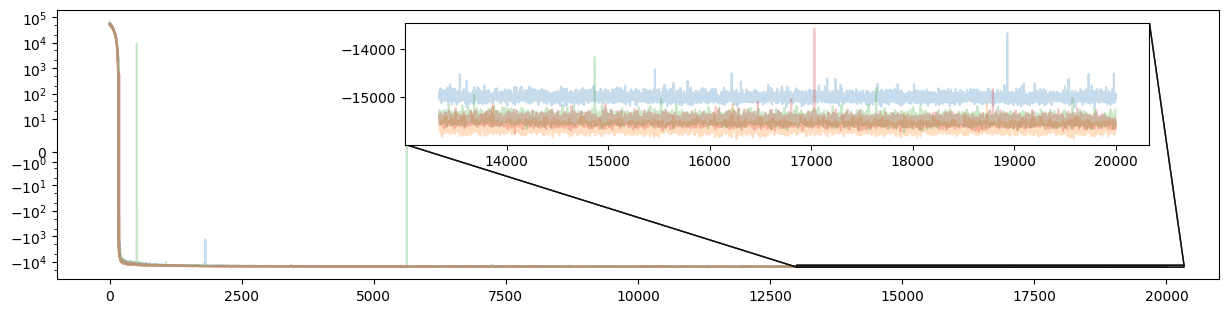

In [21]:
# Stage3: rerun pixel+PSF-correction SVI with the updated RMS map from the previous block.
# Initialization uses stage2 medians (chain-by-chain) and refines under the new noise model.

max_iterations_stage3 = max_iterations
num_chains_stage3 = num_chains

scheduler_stage3 = optax.exponential_decay(
    init_value=5e-3,
    transition_steps=200,
    decay_rate=0.99,
)
optim_stage3 = optax.adabelief(learning_rate=scheduler_stage3)
loss_stage3 = infer.TraceMeanField_ELBO()

svi_keys_stage3 = jax.random.split(jax.random.fold_in(rng_key_, 3003), num_chains_stage3)
stage3_results_list = []
stage3_guides = []

for i in range(num_chains_stage3):
    init_values_stage3_i = get_value_from_index(multi_svi_pixel_median_stage2, i) | LENS_LIGHT_FIXED_PARAMS
    init_fun_stage3_i = init_to_value_or_defer(values=init_values_stage3_i)
    guide_stage3_i = autoguide.AutoDiagonalNormal(model, init_loc_fn=init_fun_stage3_i, init_scale=0.01)
    svi_stage3_i = infer.SVI(model, guide_stage3_i, optim_stage3, loss_stage3)
    result_i = svi_stage3_i.run(
        svi_keys_stage3[i],
        max_iterations_stage3,
        data,
        **PIXELATED_STAGE3_KWARGS,
        psf_kernel=psf_hst,
        progress_bar=True,
        stable_update=True,
    )
    stage3_guides.append(guide_stage3_i)
    stage3_results_list.append(result_i)

multi_svi_pixel_results_stage3 = jax.tree.map(_stack_or_none, *stage3_results_list)
guide_pixel_stage3 = stage3_guides[0]
multi_svi_pixel_median_stage3 = guide_pixel_stage3.median(multi_svi_pixel_results_stage3.params)
multi_svi_pixel_median_herc_stage3 = median_params2kwargs(
    lambda p, fixed_params={}: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage3,
    jnp.arange(num_chains_stage3),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])
for losses in multi_svi_pixel_results_stage3.losses:
    _ = plot_loss(losses, max_iterations_stage3, ax=ax, axins=axins, alpha=0.25)

# Keep stage3 outputs as separate variables; do not overwrite stage2 variables.

# Optional stage3 diagnostic plots with corrected PSF and correction field.
stage3_psf_kernel_det, stage3_corr_field_det = get_stage2_deterministics_from_median(multi_svi_pixel_median_stage3)


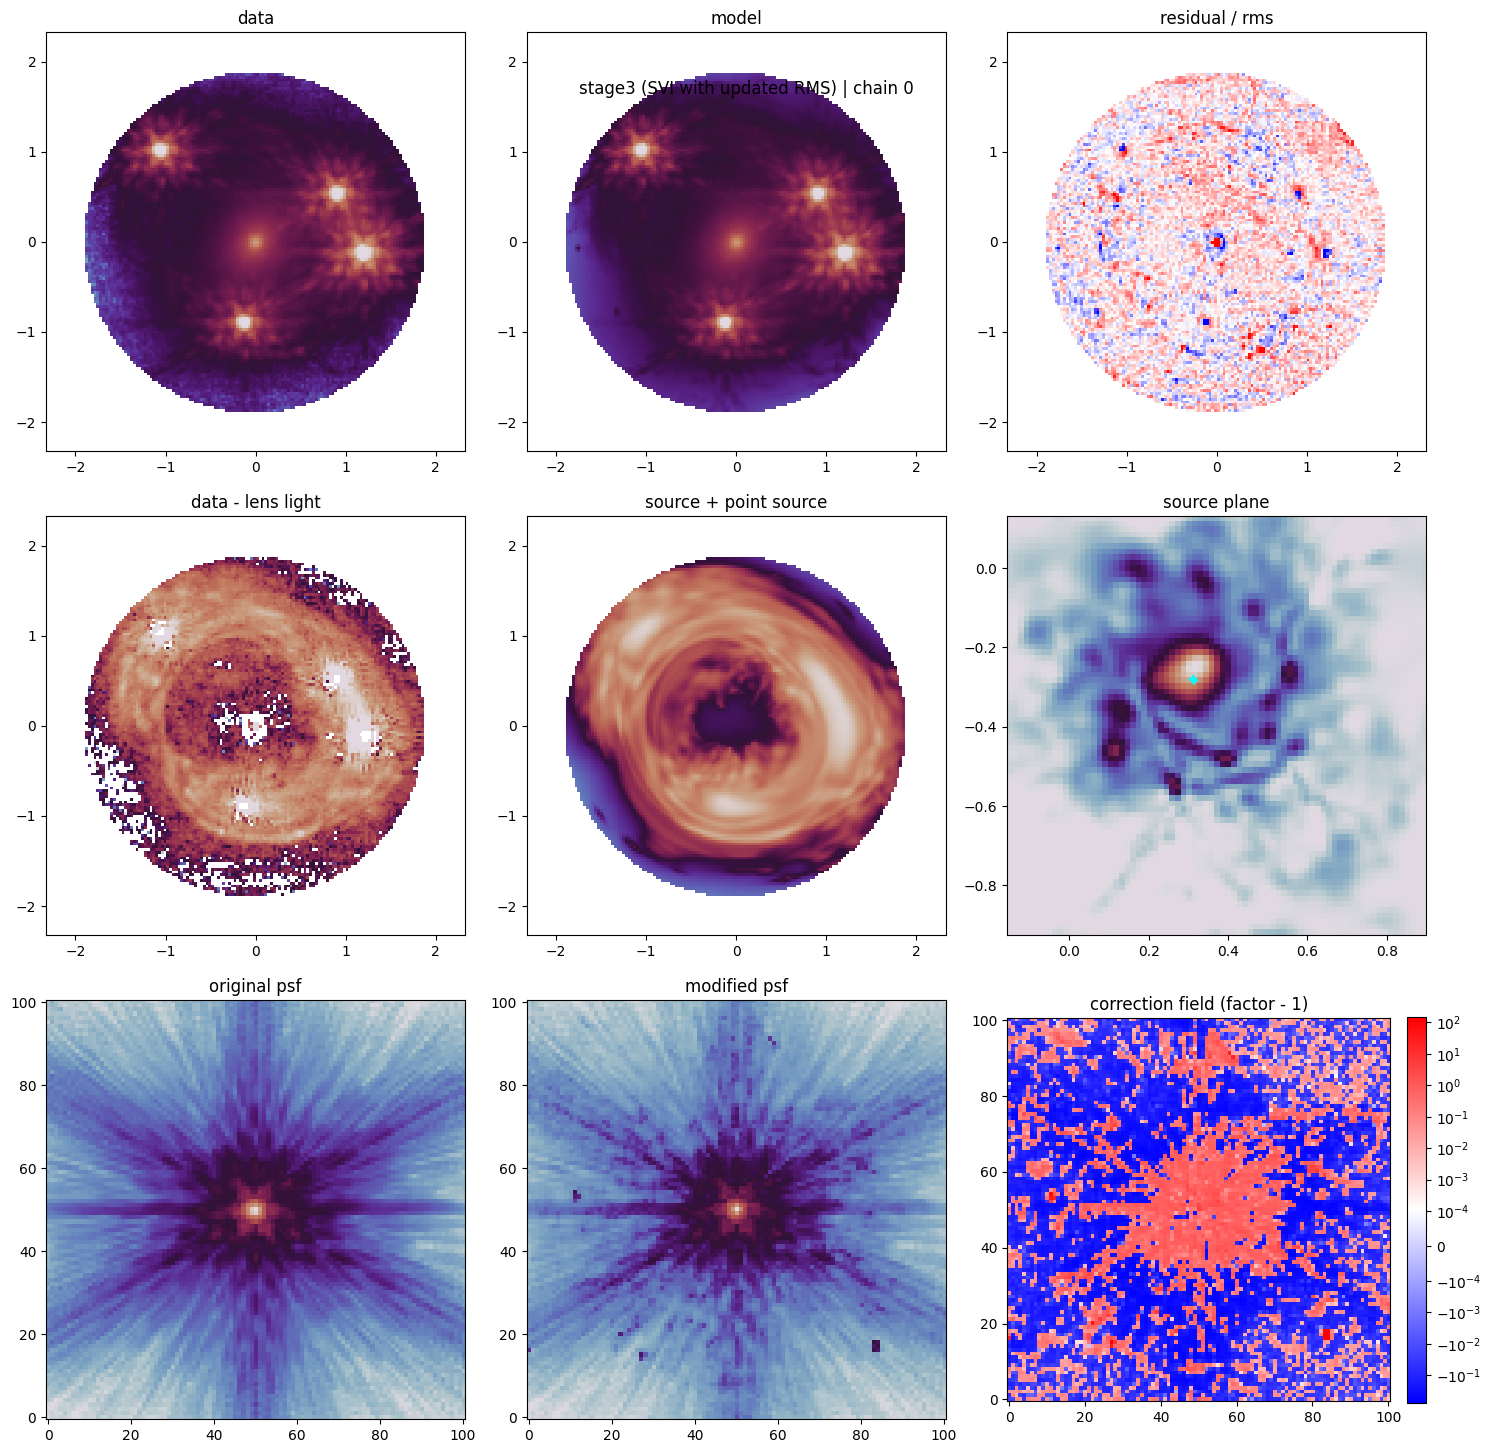

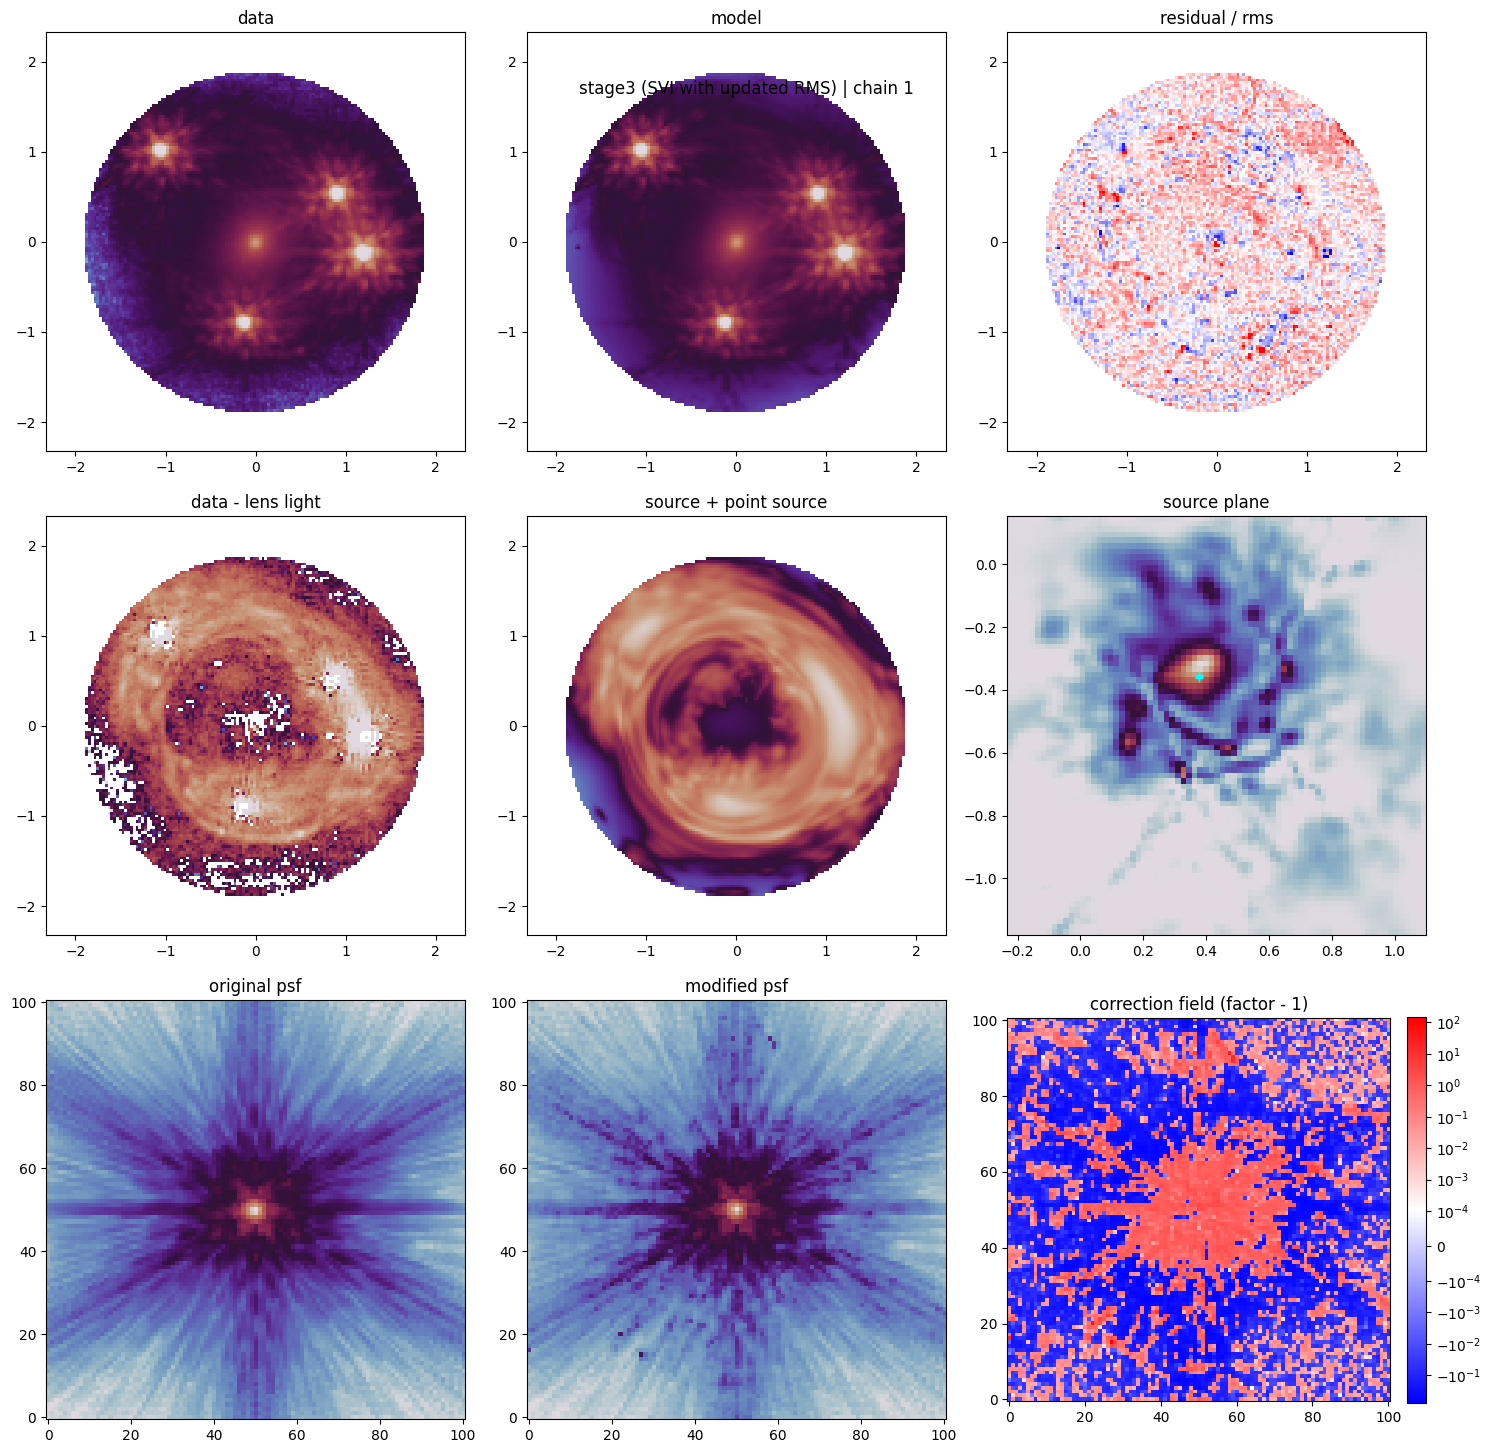

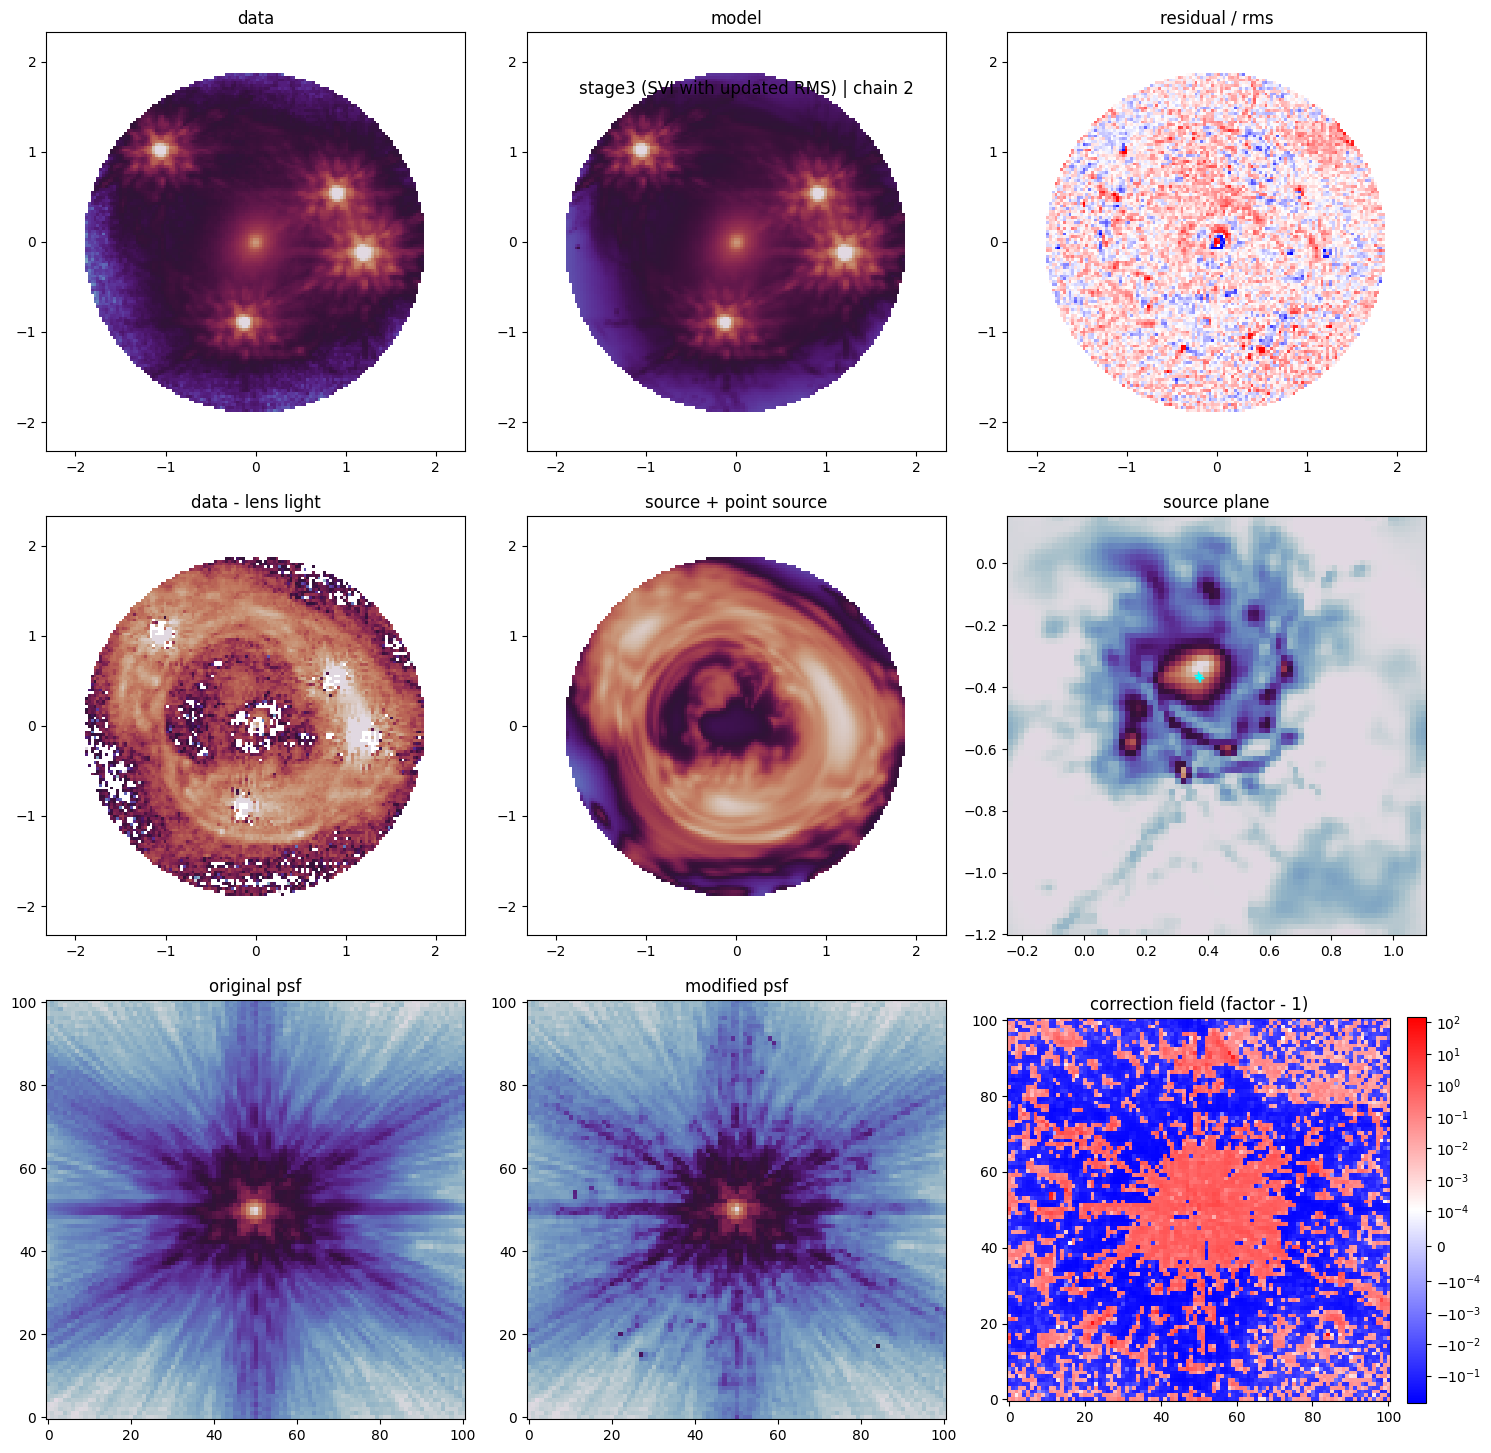

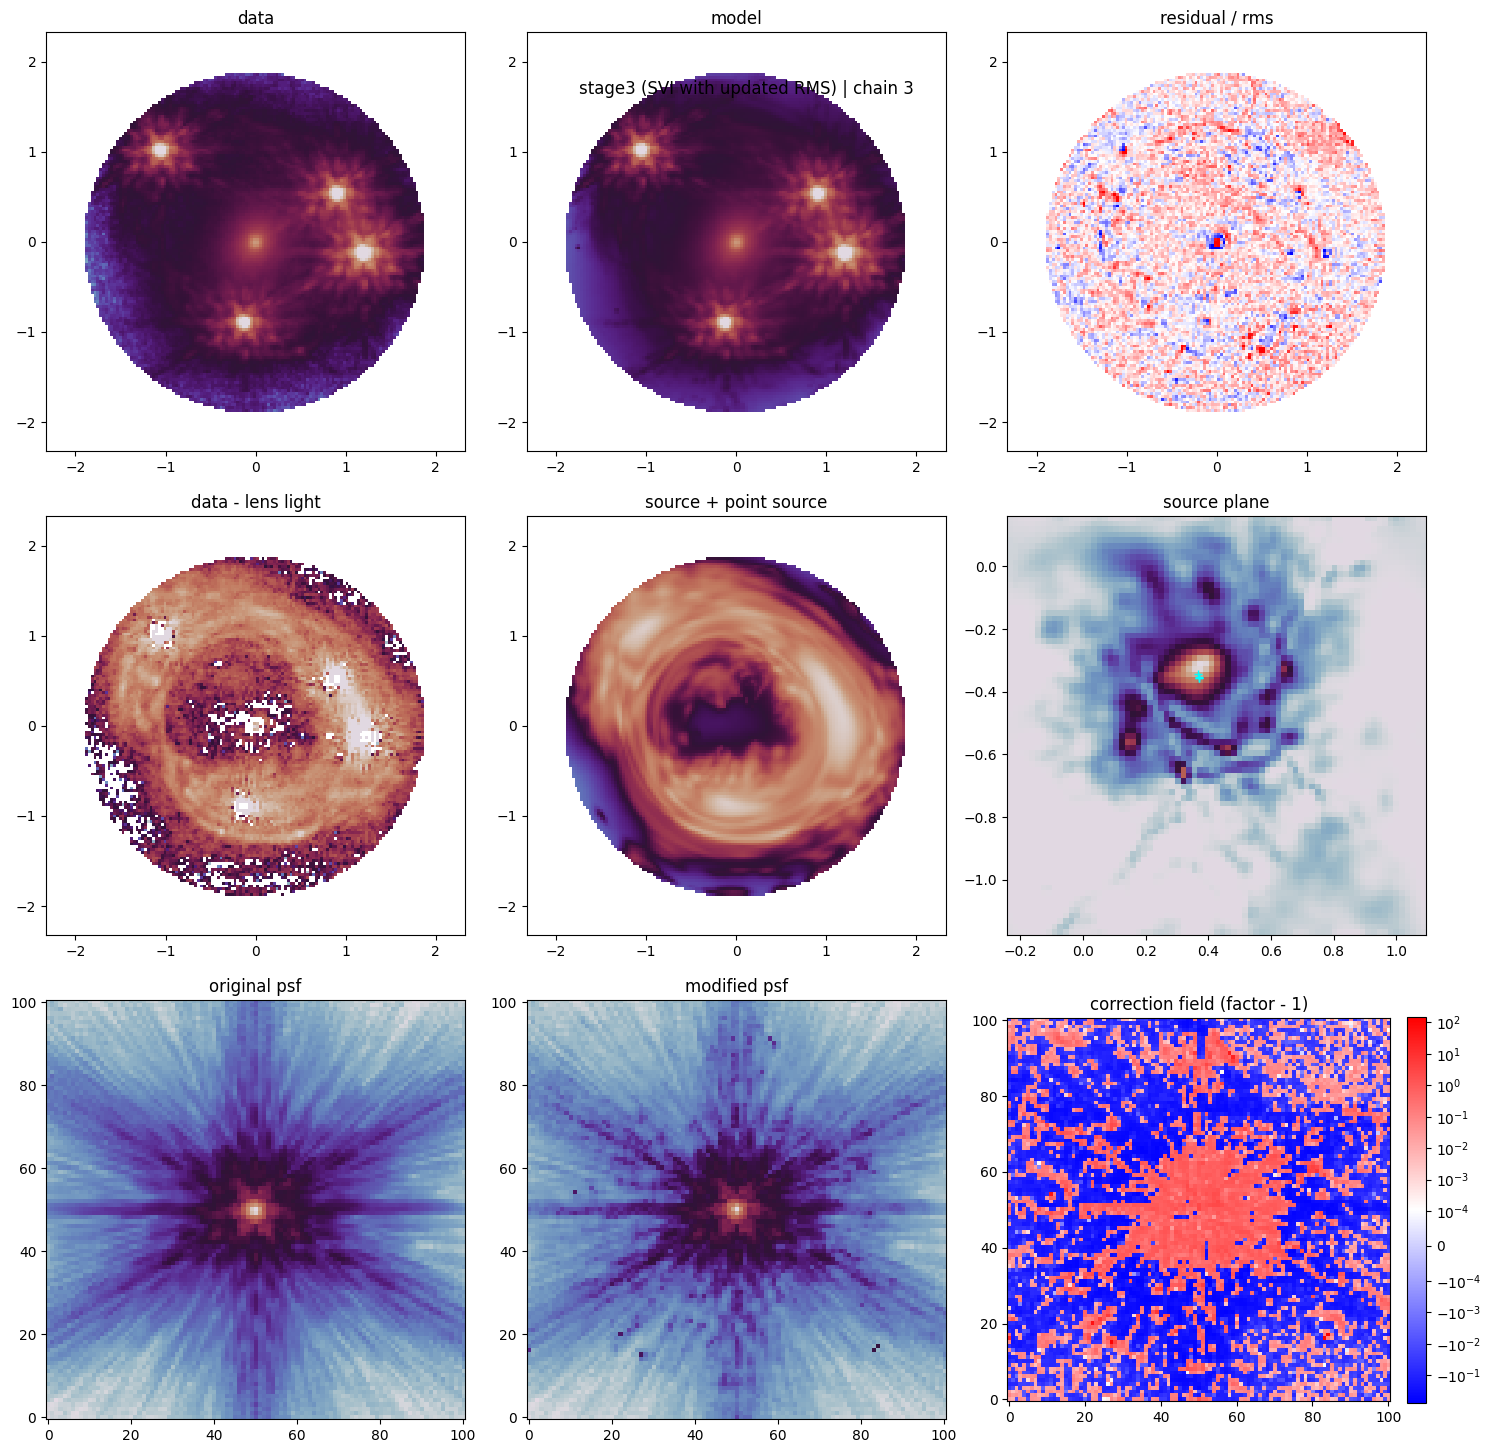

In [28]:
def plot_stage3_result_set(kwargs_all, psf_kernel_all, corr_field_all, stage_label):
    for i in range(num_chains):
        kwargs_i = get_value_from_index(kwargs_all, i)
        psf_kernel_i = get_value_from_index(psf_kernel_all, i)
        corr_field_i = get_value_from_index(corr_field_all, i)

        plt.figure(figsize=(15, 15))
        plt.suptitle(f'{stage_label} | chain {i}', y=0.92)

        plt.subplot(3, 3, 1)
        plt.imshow(np.ma.array(data, mask=~mask_out), norm='log', cmap='twilight', extent=extent, origin='lower', vmin = 0.001, vmax = 100)
        plt.title('data')

        plt.subplot(3, 3, 2)
        image_model = lens_image_pixel.model(
            **kwargs_i,
            source_add=True,
            point_source_add=True,
            psf_kernel=psf_kernel_i,
        )
        plt.imshow(np.ma.array(image_model, mask=~mask_out), norm='log', cmap='twilight', extent=extent, vmin = 0.001,vmax = 100)
        plt.title('model')

        plt.subplot(3, 3, 3)
        plt.imshow(np.ma.array((data - image_model) / rms_file, mask=~mask_out), cmap='bwr', vmax=3, vmin=-3, extent=extent)
        # plt.contour(mask, levels=[0.5], colors='black', alpha=0.95, linewidth=2, linestyles='dashed', origin='lower', extent=extent)
        plt.title('residual / rms')

        lens_light_only = lens_image_pixel.model(
            **kwargs_i,
            source_add=False,
            point_source_add=True,
            psf_kernel=psf_kernel_i,
        )

        plt.subplot(3, 3, 4)
        plt.imshow(np.ma.array(data - lens_light_only, mask=~mask_out), norm='log', cmap='twilight', extent=extent, vmax = 1, vmin = 0.0001)
        plt.title('data - lens light')

        plt.subplot(3, 3, 5)
        plt.imshow(np.ma.array(image_model - lens_light_only, mask=~mask_out), norm='log', cmap='twilight', extent=extent, vmax = 1, vmin = 0.0001)
        plt.title('source + point source')

        plt.subplot(3, 3, 6)
        source, source_extent = pixelize_plane_single(
            lens_image_pixel,
            kwargs_i,
            pixel_grid_shape,
        )
        plt.imshow(source, extent=source_extent, cmap='twilight')
        src_x, src_y = trace_current_agn_to_source(lens_image_pixel, kwargs_i)
        plt.scatter(np.array(src_x), np.array(src_y), s=40, facecolors='cyan', linewidths=1.0, marker='+',zorder=10)
        # for j, (sx, sy) in enumerate(zip(np.array(src_x), np.array(src_y)), start=1):
        #     plt.text(sx + 0.01, sy + 0.01, str(j), color='cyan', fontsize=10, weight='bold')
        plt.title('source plane')

        plt.subplot(3, 3, 7)
        plt.imshow(psf_hst, origin='lower', norm='log', cmap='twilight')
        plt.title('original psf')

        plt.subplot(3, 3, 8)
        plt.imshow(psf_kernel_i, origin='lower', norm='log', cmap='twilight')
        plt.title('modified psf')

        plt.subplot(3, 3, 9)
        plt.imshow(corr_field_i - 1.0, origin='lower', cmap='bwr', norm=colors.SymLogNorm(linthresh=1e-4))
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.title('correction field (factor - 1)')

        plt.tight_layout()
        plt.show()

plot_stage3_result_set(
    multi_svi_pixel_median_herc_stage3,
    stage3_psf_kernel_det,
    stage3_corr_field_det,
    'stage3 (SVI with updated RMS)',
)



In [23]:
get_value_from_index(multi_svi_pixel_median_stage3, 1)

{'A_lens': Array([1.15726235e+00, 1.04838995e+00, 1.15480344e+00, 1.11615108e+00,
        9.22152586e-01, 6.61034498e-01, 2.77563798e-01, 7.89498956e-02,
        3.18320424e-01, 9.98278954e+04, 9.98883492e+04, 2.91824490e+04,
        2.46192691e-02, 1.24318367e+04, 3.51178388e+03], dtype=float64),
 'amp_lens': Array([2.48172917e-10, 1.04236433e-09, 5.39632227e-09, 2.40265038e-08,
        9.02905337e-08, 3.06600919e-07, 5.79850019e-07, 7.79870547e-07,
        1.45109241e-05, 4.62144105e+01, 1.27395792e+02, 1.94148954e+02,
        5.19293569e-04, 5.87209765e+02, 2.57649028e+03], dtype=float64),
 'center_1': Array([ 0.00744483, -0.02188875], dtype=float64),
 'center_1_g1': Array([1.556], dtype=float64),
 'center_1_g2': Array([2.145], dtype=float64),
 'center_2_g1': Array([1.299], dtype=float64),
 'center_2_g2': Array([-3.326], dtype=float64),
 'center_lens': Array([[ 1.41113140e-04,  2.80261817e-02, -1.15948827e-01,
          2.06028811e-03,  1.54115203e-01, -4.50651895e-02,
         -2.4

### Corner plot (after third SVI)

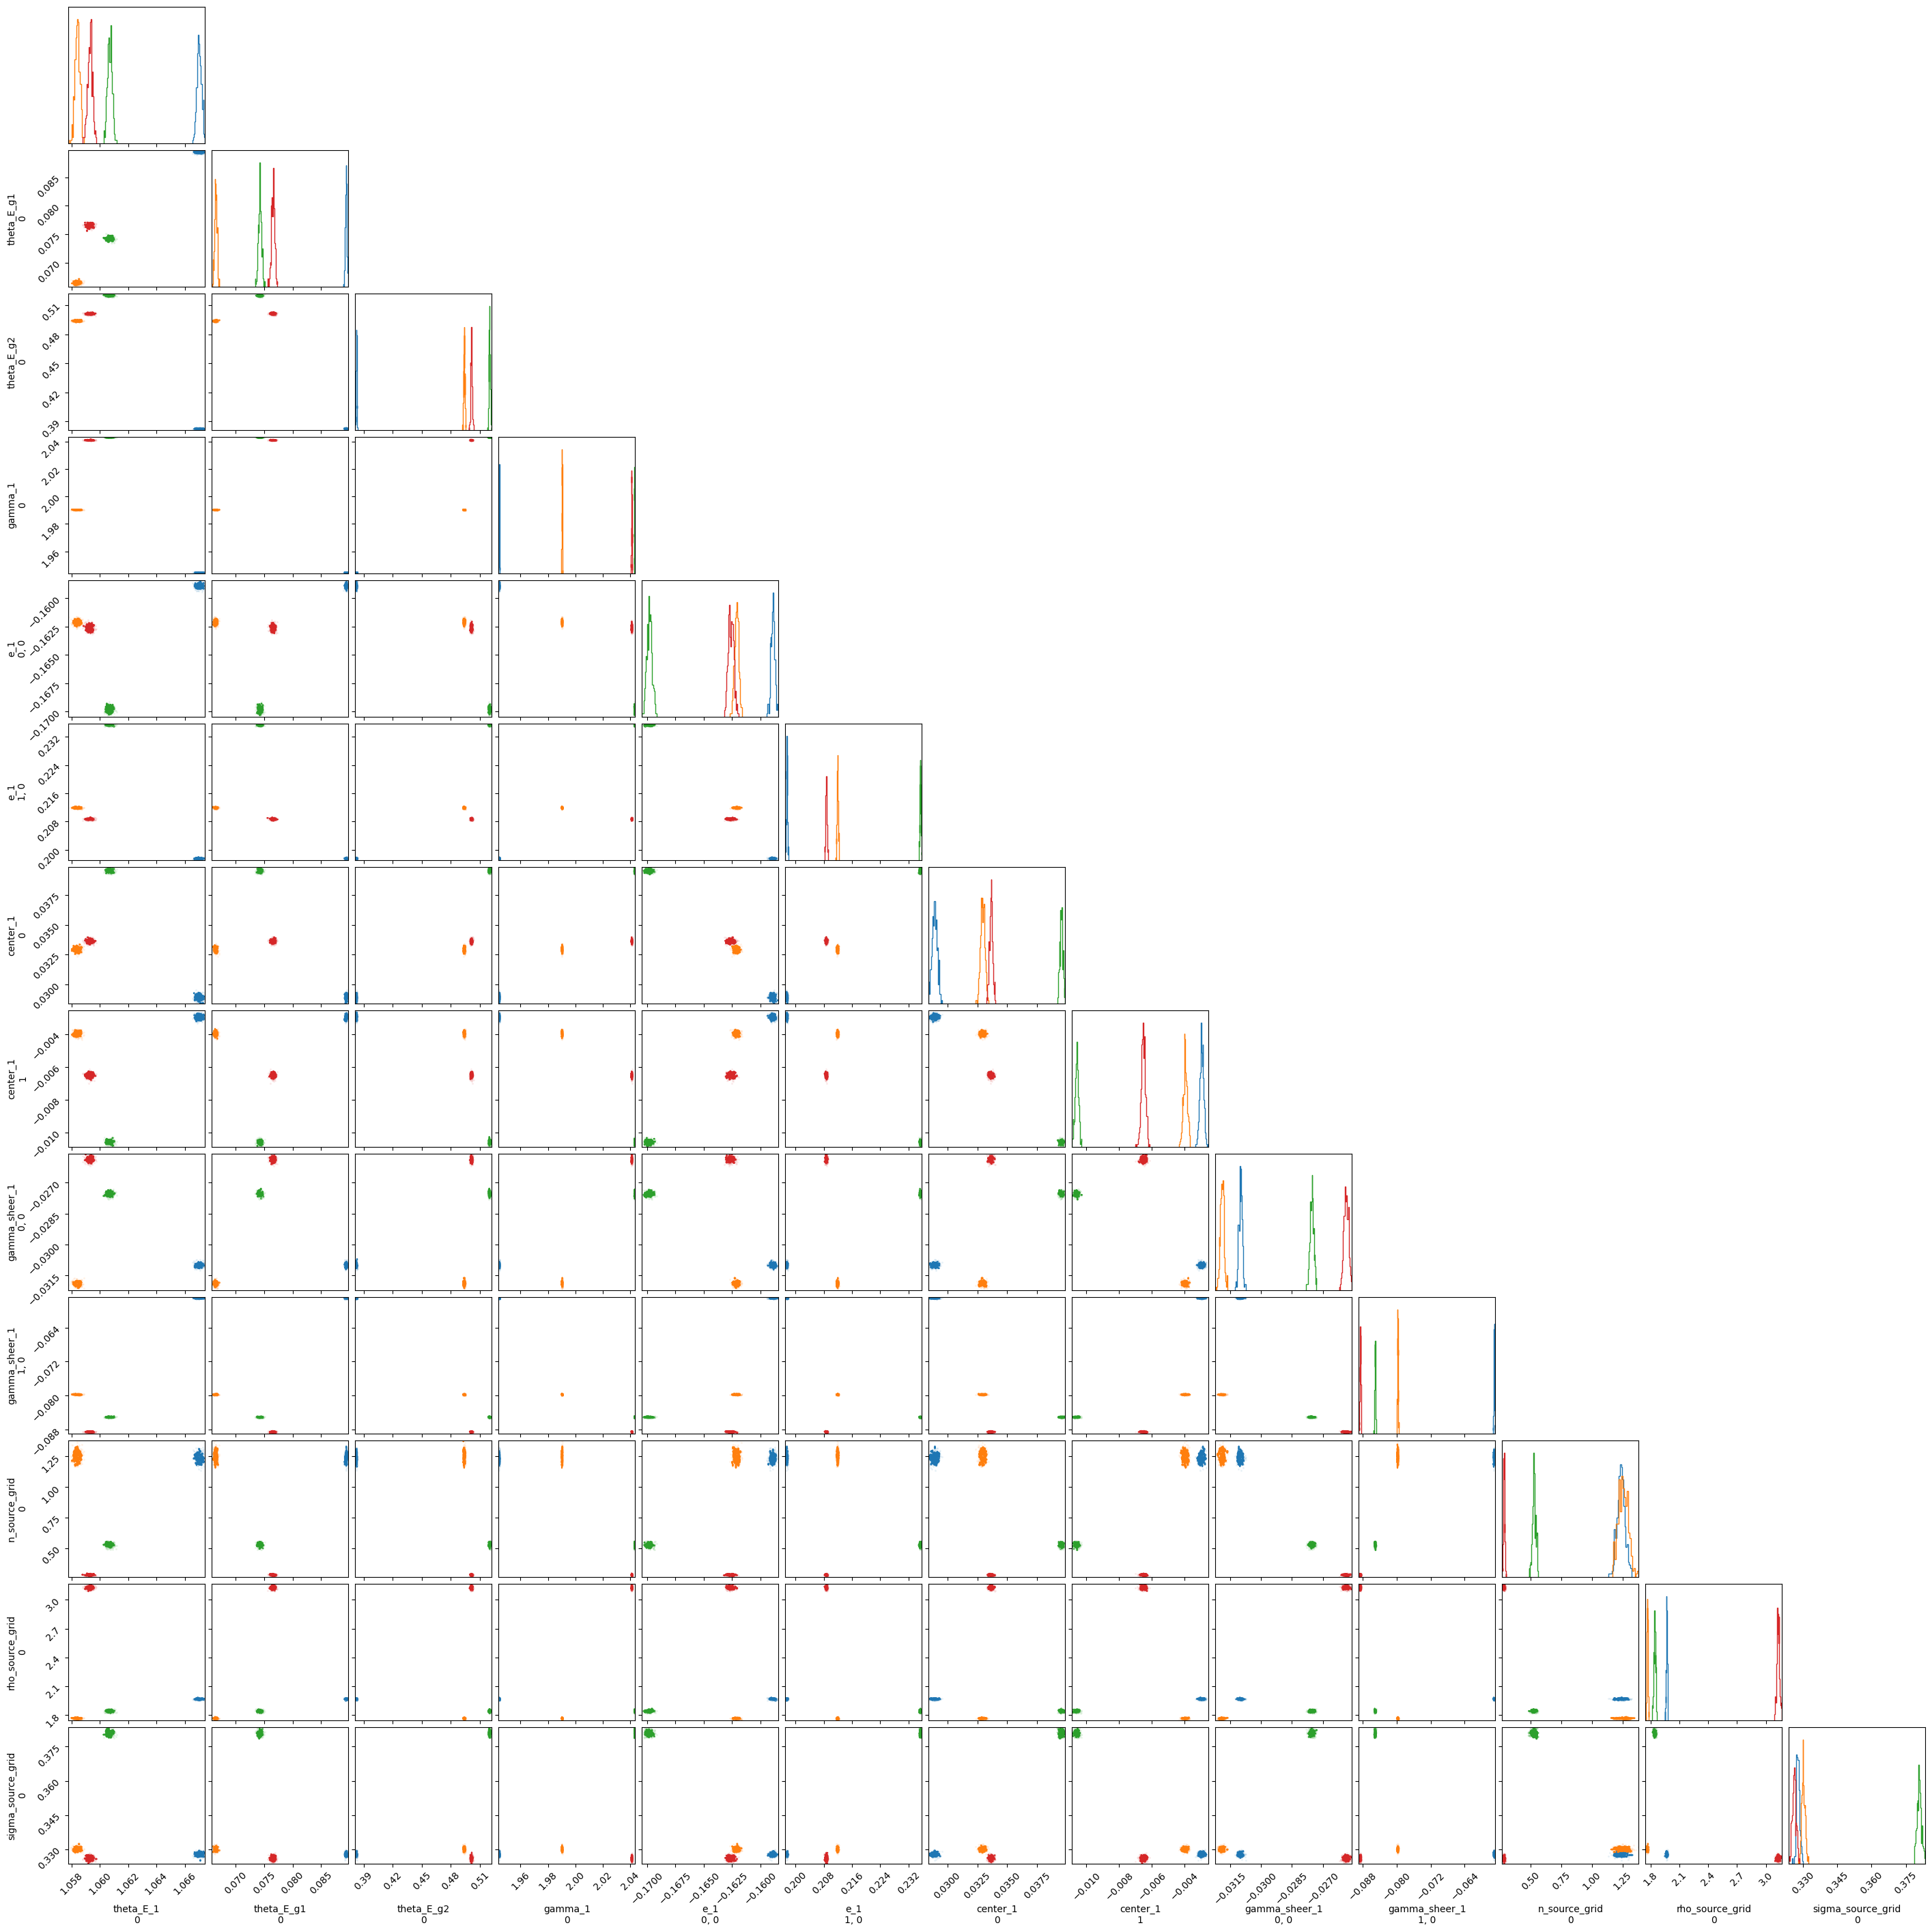

In [23]:
vars_lens_mass = ['theta_E_1', 'theta_E_g1', 'theta_E_g2', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
n_corner_draws = 300  # 不要1000，先用200-400更稳

fig_corner = None
for i in range(num_chains):
    params_i = get_value_from_index(multi_svi_pixel_results_stage2.params, i)
    key_i = jax.random.fold_in(rng_key_, i)

    # 逐链采样，降低峰值内存
    samples_all_i = guide_pixel_stage2.sample_posterior(
        key_i, params_i, sample_shape=(n_corner_draws,)
    )

    # 只保留需要画corner的参数
    samples_i = {k: samples_all_i[k] for k in vars_lens_mass+vars_power}

    # 组装成 ArviZ 需要的 (chain, draw, ...)
    posterior_i = {k: jax.device_get(v)[None, ...] for k, v in samples_i.items()}
    idata_i = az.from_dict(posterior=posterior_i)

    fig_corner = corner(
        idata_i.posterior.isel(chain=0),
        var_names=vars_lens_mass+vars_power,
        color=f'C{i}',
        fig=fig_corner,
    )


In [24]:
# best_i = int(multi_svi_pixel_results.losses[:, -1000:].mean(axis=1).argmin())

# # lens_light = params2kwargs_gauss_light(get_value_from_index(multi_svi_pixel_median, best_i), 'lens', N_gauss_light, sigma_lims_lens)
# # import pickle

# # with open('lens_light_slice.pkl', 'wb') as f:
# #     pickle.dump(lens_light, f)

# # vars_fixed = vars_lens_light 
# # svi_pixel_median = get_value_from_index(multi_svi_pixel_median, best_i)
# # fixed_params_pixel = {k:svi_pixel_median[k] for k in vars_fixed}
# # model_pixel_hmc_new = condition(model, fixed_params_pixel)